## Setup


In [1]:
# ============================================================
# PHASE 3 — PATHS AND DATA
# ============================================================

import os
import json
import math
import random
import re
from pathlib import Path
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm


SEED = 42

random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Reasoning dataset generated in previous step
# ------------------------------------------------------------

DATA_DIR = Path(
    "/kaggle/input/datasets/tanoojtadepalli/final-telugu-phase3/telugu_reasoning_dataset_shared_names"
)

TRAIN_FILE = DATA_DIR / "train.jsonl"
VAL_FILE = DATA_DIR / "validation.jsonl"
TEST_FILE = DATA_DIR / "test.jsonl"


# ------------------------------------------------------------
# Phase 3 output directory
# ------------------------------------------------------------

PHASE3_DIR = Path(
    "/kaggle/working/telugu_phase3"
)

PHASE3_DIR.mkdir(
    parents=True,
    exist_ok=True
)

ATTENTION_DIR = PHASE3_DIR / "attention"

ATTENTION_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# Pretrained checkpoint
#
# This variable already exists in your notebook:
#
checkpoint_path ="/kaggle/input/datasets/sukaramba/telugu-model-files/checkpoints_telugu/telugu_latest_ckpt.pt"
# ------------------------------------------------------------

PRETRAINED_CHECKPOINT = checkpoint_path


assert TRAIN_FILE.exists(), TRAIN_FILE
assert VAL_FILE.exists(), VAL_FILE
assert TEST_FILE.exists(), TEST_FILE
assert os.path.exists(PRETRAINED_CHECKPOINT)


def load_jsonl(path):
    examples = []

    with open(
        path,
        "r",
        encoding="utf-8"
    ) as f:

        for line in f:
            examples.append(
                json.loads(line)
            )

    return examples


train_examples = load_jsonl(TRAIN_FILE)
val_examples = load_jsonl(VAL_FILE)
test_examples = load_jsonl(TEST_FILE)


print("Train      :", len(train_examples))
print("Validation :", len(val_examples))
print("Test       :", len(test_examples))

assert len(train_examples) == 9600
assert len(val_examples) == 1200
assert len(test_examples) == 1200

print("\n✓ Reasoning dataset loaded.")

Train      : 9600
Validation : 1200
Test       : 1200

✓ Reasoning dataset loaded.


In [2]:
print("TRAIN FILE:", TRAIN_FILE)
print("VAL FILE  :", VAL_FILE)
print("TEST FILE :", TEST_FILE)




TRAIN FILE: /kaggle/input/datasets/tanoojtadepalli/final-telugu-phase3/telugu_reasoning_dataset_shared_names/train.jsonl
VAL FILE  : /kaggle/input/datasets/tanoojtadepalli/final-telugu-phase3/telugu_reasoning_dataset_shared_names/validation.jsonl
TEST FILE : /kaggle/input/datasets/tanoojtadepalli/final-telugu-phase3/telugu_reasoning_dataset_shared_names/test.jsonl


## Finetuning hyperparameters


In [3]:
# ============================================================
# FINETUNING CONFIGURATION
# ============================================================

FT_CONFIG = {
    "epochs": 3,
    "batch_size": 16,
    "learning_rate": 5e-5,
    "weight_decay": 0.01,
    "max_length": 256,
    "gradient_clip": 1.0,
    "warmup_ratio": 0.05,
    "seed": 42,
}

print(FT_CONFIG)


# Save hyperparameters for reproducibility

with open(
    PHASE3_DIR / "finetune_config.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        FT_CONFIG,
        f,
        indent=2
    )

{'epochs': 3, 'batch_size': 16, 'learning_rate': 5e-05, 'weight_decay': 0.01, 'max_length': 256, 'gradient_clip': 1.0, 'warmup_ratio': 0.05, 'seed': 42}


## Load the Phase-1 SentencePiece tokenizer



In [4]:
# ============================================================
# LOAD TELUGU TOKENIZER FROM KAGGLE INPUT
# ============================================================

import os
import sentencepiece as spm


# Search Kaggle inputs for telugu_sp.model
tokenizer_path = "/kaggle/input/models/tanoojtadepalli/telugu-tokenizer/pytorch/default/1/telugu_sp.model"

for root, dirs, files in os.walk("/kaggle/input"):
    if "telugu_sp.model" in files:
        tokenizer_path = os.path.join(
            root,
            "telugu_sp.model"
        )
        break


# Make sure tokenizer was found
assert tokenizer_path is not None, (
    "telugu_sp.model was not found in /kaggle/input"
)


print("Tokenizer path:")
print(tokenizer_path)


# Load SAME tokenizer trained in Phase 1
sp = spm.SentencePieceProcessor(
    model_file=tokenizer_path
)


print("\n✓ Telugu tokenizer loaded successfully")

print("Vocabulary size :", sp.get_piece_size())
print("PAD ID          :", sp.pad_id())
print("BOS ID          :", sp.bos_id())
print("EOS ID          :", sp.eos_id())
print("UNK ID          :", sp.unk_id())

Tokenizer path:
/kaggle/input/models/tanoojtadepalli/telugu-tokenizer/pytorch/default/1/telugu_sp.model

✓ Telugu tokenizer loaded successfully
Vocabulary size : 10000
PAD ID          : 0
BOS ID          : 2
EOS ID          : 3
UNK ID          : 1


## Dataset, collate function, and dataloaders (first definition)

Sets the Telugu prompt format (`ప్రశ్న:` / `సమాధానం:`).
Tokenizes prompt and answer separately, concatenates them into one sequence, and builds labels as `[-100] * len(prompt) + answer_ids`. **`-100` is ignored by the loss**, so the question is context only


In [5]:
# ============================================================
# PYTORCH REASONING DATASET
# ============================================================

QUESTION_PREFIX = "ప్రశ్న:\n"
ANSWER_PREFIX = "\nసమాధానం:\n"

MAX_LENGTH = FT_CONFIG["max_length"]


# ------------------------------------------------------------
# Padding token
# ------------------------------------------------------------

PAD_ID = sp.pad_id()

if PAD_ID < 0:

    if sp.eos_id() >= 0:
        PAD_ID = sp.eos_id()
    else:
        PAD_ID = 0


EOS_ID = sp.eos_id()

print("PAD ID:", PAD_ID)
print("EOS ID:", EOS_ID)


class ReasoningDataset(Dataset):

    def __init__(
        self,
        examples,
        tokenizer,
        max_length
    ):

        self.examples = examples
        self.tokenizer = tokenizer
        self.max_length = max_length


    def __len__(self):

        return len(self.examples)


    def __getitem__(self, index):

        example = self.examples[index]

        prompt_text = (
            QUESTION_PREFIX
            + example["prompt"]
            + ANSWER_PREFIX
        )

        answer_text = example["answer"]


        # Prompt tokens
        prompt_ids = self.tokenizer.encode(
            prompt_text,
            out_type=int
        )


        # Answer tokens
        answer_ids = self.tokenizer.encode(
            answer_text,
            out_type=int
        )


        # Complete sequence
        input_ids = (
            prompt_ids
            + answer_ids
        )


        # Add EOS if tokenizer contains one
        if EOS_ID >= 0:
            input_ids.append(EOS_ID)


        # ----------------------------------------------------
        # Labels
        #
        # -100 means:
        # do NOT calculate loss for these tokens.
        #
        # Therefore prompt is context,
        # while answer is supervised.
        # ----------------------------------------------------

        labels = (
            [-100] * len(prompt_ids)
            + answer_ids
        )

        if EOS_ID >= 0:
            labels.append(EOS_ID)


        # Reasoning examples should be short.
        # We assert rather than silently truncating.
        assert len(input_ids) <= self.max_length, (
            f"Example exceeds max length: "
            f"{len(input_ids)}"
        )


        return {
            "input_ids": torch.tensor(
                input_ids,
                dtype=torch.long
            ),

            "labels": torch.tensor(
                labels,
                dtype=torch.long
            ),

            "template": example["template"],
        }


# ============================================================
# COLLATE FUNCTION
# ============================================================

def collate_batch(batch):

    batch_size = len(batch)

    max_len = max(
        len(item["input_ids"])
        for item in batch
    )

    input_ids = torch.full(
        (batch_size, max_len),
        PAD_ID,
        dtype=torch.long
    )

    labels = torch.full(
        (batch_size, max_len),
        -100,
        dtype=torch.long
    )


    for i, item in enumerate(batch):

        length = len(
            item["input_ids"]
        )

        input_ids[i, :length] = (
            item["input_ids"]
        )

        labels[i, :length] = (
            item["labels"]
        )


    return input_ids, labels


train_dataset = ReasoningDataset(
    train_examples,
    sp,
    MAX_LENGTH
)

val_dataset = ReasoningDataset(
    val_examples,
    sp,
    MAX_LENGTH
)


train_loader = DataLoader(
    train_dataset,
    batch_size=FT_CONFIG["batch_size"],
    shuffle=True,
    collate_fn=collate_batch,
    num_workers=2,
    pin_memory=True
)


val_loader = DataLoader(
    val_dataset,
    batch_size=FT_CONFIG["batch_size"],
    shuffle=False,
    collate_fn=collate_batch,
    num_workers=2,
    pin_memory=True
)


print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))


# Sanity check

input_ids, labels = next(
    iter(train_loader)
)

print("\nInput shape :", input_ids.shape)
print("Label shape :", labels.shape)

PAD ID: 0
EOS ID: 3
Train batches: 600
Validation batches: 75

Input shape : torch.Size([16, 79])
Label shape : torch.Size([16, 79])


## Greedy decoding + answer normalisation

The model repeatedly picks the most likely next token, adds it to the input, and uses the updated input to predict the next token until it finishes.

`normalize_answer` strip whitespace, drop trailing punctuation including the Devanagari danda, and collapse repeated spaces.


In [6]:
# ============================================================
# GREEDY REASONING GENERATION
# ============================================================

@torch.inference_mode()
def generate_reasoning_answer(
    model,
    prompt,
    max_new_tokens=12
):

    model.eval()

    prefix = (
        QUESTION_PREFIX
        + prompt
        + ANSWER_PREFIX
    )

    ids = sp.encode(
        prefix,
        out_type=int
    )

    input_ids = torch.tensor(
        ids,
        dtype=torch.long,
        device=device
    ).unsqueeze(0)


    generated_ids = []


    for _ in range(max_new_tokens):

        context = input_ids[
            :,
            -config["max_seq_len"]:
        ]

        logits = model(context)

        next_token = torch.argmax(
            logits[:, -1, :],
            dim=-1,
            keepdim=True
        )

        token_id = (
            next_token.item()
        )


        # Stop at EOS
        if EOS_ID >= 0 and token_id == EOS_ID:
            break


        generated_ids.append(
            token_id
        )


        input_ids = torch.cat(
            [
                input_ids,
                next_token
            ],
            dim=1
        )


    text = sp.decode(
        generated_ids
    )

    return text


# ============================================================
# NORMALIZE ANSWER
# ============================================================

def normalize_answer(text):

    text = text.strip()

    # Take first output line
    if "\n" in text:
        text = text.split("\n")[0]

    text = text.strip()

    # Remove common trailing punctuation
    text = text.strip(
        " \t\r\n.,!?;:।-–—"
    )

    # Normalize repeated spaces
    text = " ".join(
        text.split()
    )

    return text

## Exact-match evaluation 
The code tests the model on examples, compares its predicted answers with the correct answers, and calculates overall and template-wise accuracy.


In [7]:
# ============================================================
# EXACT MATCH EVALUATION
# ============================================================

def evaluate_reasoning(
    model,
    examples,
    description
):

    results = []

    correct = 0

    template_correct = defaultdict(int)
    template_total = defaultdict(int)


    for example in tqdm(
        examples,
        desc=description
    ):

        predicted = (
            generate_reasoning_answer(
                model,
                example["prompt"]
            )
        )

        predicted_clean = normalize_answer(
            predicted
        )

        gold_clean = normalize_answer(
            example["answer"]
        )

        is_correct = (
            predicted_clean
            == gold_clean
        )


        if is_correct:
            correct += 1

        template = example["template"]

        template_total[template] += 1

        if is_correct:
            template_correct[template] += 1


        results.append({
            "id": example["id"],
            "template": template,
            "prompt": example["prompt"],
            "gold": gold_clean,
            "prediction": predicted_clean,
            "correct": is_correct,
        })


    overall_accuracy = (
        correct / len(examples)
    )


    template_accuracy = {}

    for template in sorted(
        template_total
    ):

        template_accuracy[template] = (
            template_correct[template]
            / template_total[template]
        )


    metrics = {
        "overall_exact_match":
            overall_accuracy,

        "template_accuracy":
            template_accuracy,
    }


    return metrics, results

## Device selection

Picks CUDA when available, else CPU.


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


## Model architecture config

The Phase-2 architecture: 12 layers, `d_model` 384, 8 heads, FFN 1536, vocab 10k, context 512, dropout 0.1 — roughly a 25M-parameter GPT-style decoder.



In [9]:
config = {
    "vocab_size": 10000,
    "max_seq_len": 512,
    "qkv_bias": False,
    "d_model": 384,
    "n_layers": 12,
    "n_heads": 8,
    "d_ff": 1536,
    "dropout": 0.1,
}

## Import block 


In [10]:
# ============================================================
# CELL 14 — IMPORTS AND DEVICE
# ============================================================

import os
import json
import math
import random

from pathlib import Path
from collections import Counter, defaultdict

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

import sentencepiece as spm

from tqdm.auto import tqdm


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
Device: cuda
GPU: Tesla T4


## Phase-2 transformer definition

The full model, re-declared here so the checkpoint loads into an identical class:



In [11]:
# ============================================================
# CELL 15 — EXACT PHASE 2 TRANSFORMER MODEL
# ============================================================


# ============================================================
# LAYER NORMALIZATION
# ============================================================

class LayerNorm(nn.Module):

    def __init__(self, emb_dim):

        super().__init__()

        self.eps = 1e-5

        self.scale = nn.Parameter(
            torch.ones(emb_dim)
        )

        self.shift = nn.Parameter(
            torch.zeros(emb_dim)
        )


    def forward(self, x):

        return F.layer_norm(
            x,
            normalized_shape=(x.size(-1),),
            weight=self.scale,
            bias=self.shift,
            eps=self.eps,
        )


# ============================================================
# GELU
# ============================================================

class GeLU(nn.Module):

    def forward(self, x):

        return F.gelu(x)


# ============================================================
# MULTI-HEAD CAUSAL SELF-ATTENTION
# ============================================================

class MultiHeadAttention(nn.Module):

    def __init__(
        self,
        d_in,
        d_out,
        context_length,
        dropout,
        num_heads,
        qkv_bias=False
    ):

        super().__init__()

        assert d_out % num_heads == 0

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.scale = self.head_dim ** -0.5


        self.qkv = nn.Linear(
            d_in,
            3 * d_out,
            bias=qkv_bias
        )


        self.out_proj = nn.Linear(
            d_out,
            d_out
        )


        self.dropout = nn.Dropout(
            dropout
        )


        self.register_buffer(
            "mask",
            torch.triu(
                torch.ones(
                    context_length,
                    context_length,
                    dtype=torch.bool
                ),
                diagonal=1
            )
        )


    def forward(
        self,
        x,
        return_attention=False
    ):

        B, T, C = x.shape


        if T > self.mask.size(0):

            raise ValueError(
                f"T={T} exceeds context length "
                f"{self.mask.size(0)}"
            )


        # Combined QKV
        qkv = self.qkv(x)


        q, k, v = qkv.chunk(
            3,
            dim=-1
        )


        # Split heads
        q = q.view(
            B,
            T,
            self.num_heads,
            self.head_dim
        ).transpose(1, 2)


        k = k.view(
            B,
            T,
            self.num_heads,
            self.head_dim
        ).transpose(1, 2)


        v = v.view(
            B,
            T,
            self.num_heads,
            self.head_dim
        ).transpose(1, 2)


        # Scale queries
        q = q * self.scale


        # Attention scores
        scores = (
            q @ k.transpose(-2, -1)
        )


        # Causal mask
        scores = scores.masked_fill(
            self.mask[:T, :T],
            torch.finfo(scores.dtype).min
        )


        attn_probs = F.softmax(
            scores,
            dim=-1
        )


        attn_used = self.dropout(
            attn_probs
        )


        context = (
            attn_used @ v
        )


        context = (
            context
            .transpose(1, 2)
            .contiguous()
            .view(
                B,
                T,
                self.d_out
            )
        )


        context = self.out_proj(
            context
        )


        if return_attention:

            return context, attn_probs


        return context


# ============================================================
# FEED FORWARD
# ============================================================

class FeedForward(nn.Module):

    def __init__(self, config):

        super().__init__()

        d_model = config["d_model"]
        d_ff = config["d_ff"]


        self.layer1 = nn.Linear(
            d_model,
            d_ff
        )


        self.gelu = GeLU()


        self.layer2 = nn.Linear(
            d_ff,
            d_model
        )


        # Keep same structure as Phase 2 checkpoint
        self.layer = nn.Sequential(
            self.layer1,
            self.gelu,
            self.layer2
        )


    def forward(self, x):

        x = self.layer1(x)

        x = F.gelu(x)

        x = self.layer2(x)

        return x


# ============================================================
# TRANSFORMER BLOCK
# ============================================================

class TransformerBlock(nn.Module):

    def __init__(self, cfg):

        super().__init__()


        self.att = MultiHeadAttention(
            d_in=cfg["d_model"],
            d_out=cfg["d_model"],
            context_length=cfg["max_seq_len"],
            dropout=cfg["dropout"],
            num_heads=cfg["n_heads"],
            qkv_bias=cfg["qkv_bias"]
        )


        self.ff = FeedForward(
            cfg
        )


        self.norm1 = LayerNorm(
            cfg["d_model"]
        )


        self.norm2 = LayerNorm(
            cfg["d_model"]
        )


        self.drop_shortcut = nn.Dropout(
            cfg["dropout"]
        )


    def forward(
        self,
        x,
        return_attention=False
    ):

        # -----------------------------
        # ATTENTION
        # -----------------------------

        shortcut = x

        normed = self.norm1(x)


        if return_attention:

            att_out, attn = self.att(
                normed,
                return_attention=True
            )

        else:

            att_out = self.att(
                normed
            )


        x = shortcut + self.drop_shortcut(
            att_out
        )


        # -----------------------------
        # FEED FORWARD
        # -----------------------------

        shortcut = x


        ff_out = self.ff(
            self.norm2(x)
        )


        x = shortcut + self.drop_shortcut(
            ff_out
        )


        if return_attention:

            return x, attn


        return x


# ============================================================
# COMPLETE TRANSFORMER
# ============================================================

class Transformer(nn.Module):

    def __init__(self, config):

        super().__init__()

        self.config = dict(config)


        # Token embeddings
        self.tok_emb = nn.Embedding(
            config["vocab_size"],
            config["d_model"]
        )


        # Positional embeddings
        self.position_emb = nn.Embedding(
            config["max_seq_len"],
            config["d_model"]
        )


        self.dropout = nn.Dropout(
            config["dropout"]
        )


        # Transformer blocks
        self.trf_blocks = nn.ModuleList(
            [
                TransformerBlock(config)

                for _ in range(
                    config["n_layers"]
                )
            ]
        )


        self.final_ln = LayerNorm(
            config["d_model"]
        )


        self.out_layer = nn.Linear(
            config["d_model"],
            config["vocab_size"],
            bias=False
        )


        self.apply(
            self._init_weights
        )


        # Weight tying
        self.out_layer.weight = (
            self.tok_emb.weight
        )


    @staticmethod
    def _init_weights(module):

        if isinstance(
            module,
            nn.Linear
        ):

            nn.init.normal_(
                module.weight,
                mean=0.0,
                std=0.02
            )


            if module.bias is not None:

                nn.init.zeros_(
                    module.bias
                )


        elif isinstance(
            module,
            nn.Embedding
        ):

            nn.init.normal_(
                module.weight,
                mean=0.0,
                std=0.02
            )


    def forward(
        self,
        in_idx,
        return_attentions=False
    ):

        B, T = in_idx.shape


        if T > self.config["max_seq_len"]:

            raise ValueError(
                f"T={T} exceeds max_seq_len="
                f"{self.config['max_seq_len']}"
            )


        positions = torch.arange(
            T,
            device=in_idx.device
        )


        x = (
            self.tok_emb(in_idx)
            + self.position_emb(positions)
        )


        x = self.dropout(x)


        attentions = []


        for block in self.trf_blocks:

            if return_attentions:

                x, attn = block(
                    x,
                    return_attention=True
                )

                attentions.append(
                    attn
                )

            else:

                x = block(x)


        x = self.final_ln(x)


        logits = self.out_layer(x)


        if return_attentions:

            return logits, attentions


        return logits

## Verify the model class and count parameters


In [12]:
# ============================================================
# CELL 16 — VERIFY MODEL CLASS
# ============================================================

assert "Transformer" in globals()

print("Transformer class exists:")
print(Transformer)


test_model = Transformer(
    config
).to(device)


parameter_count = sum(
    p.numel()
    for p in test_model.parameters()
)


print(
    f"\nParameter count: "
    f"{parameter_count:,}"
)


del test_model

if torch.cuda.is_available():
    torch.cuda.empty_cache()

Transformer class exists:
<class '__main__.Transformer'>

Parameter count: 25,317,120


## Locate the Phase-2 checkpoint



In [13]:
# ============================================================
# CELL 18 — FIND PHASE 2 CHECKPOINT
# ============================================================

checkpoint_candidates = []


for root, dirs, files in os.walk(
    "/kaggle/input"
):

    for filename in files:

        if filename.endswith(
            (".pt", ".pth")
        ):

            full_path = os.path.join(
                root,
                filename
            )

            if "telugu" in full_path.lower():

                checkpoint_candidates.append(
                    full_path
                )


print("Checkpoint files found:\n")

for path in checkpoint_candidates:
    print(path)


assert len(checkpoint_candidates) > 0, (
    "No Telugu checkpoint found!"
)

Checkpoint files found:

/kaggle/input/datasets/sukaramba/telugu-model-files/checkpoints_telugu/telugu_latest_ckpt.pt
/kaggle/input/datasets/sukaramba/telugu-model-files/checkpoints_telugu/telugu_step_25000.pt
/kaggle/input/datasets/sukaramba/telugu-model-files/checkpoints_telugu/telugu_step_30000.pt


## Load the pretrained weights




In [14]:
# ============================================================
# CELL 19 — LOAD PHASE 2 PRETRAINED MODEL
# ============================================================

latest_candidates = [
    path
    for path in checkpoint_candidates
    if "latest" in path.lower()
]


if len(latest_candidates) > 0:

    checkpoint_path = (
        latest_candidates[0]
    )

else:

    checkpoint_path = (
        checkpoint_candidates[0]
    )


print(
    "Using checkpoint:"
)

print(
    checkpoint_path
)


# ------------------------------------------------------------
# Create model
# ------------------------------------------------------------

model = Transformer(
    config
).to(device)


# ------------------------------------------------------------
# Load checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False
)


print(
    "\nCheckpoint keys:"
)

print(
    checkpoint.keys()
)


# ------------------------------------------------------------
# Load pretrained weights
# ------------------------------------------------------------

model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ],
    strict=True
)


model.eval()


print(
    "\n✓ Phase 2 Telugu pretrained "
    "model loaded successfully."
)

Using checkpoint:
/kaggle/input/datasets/sukaramba/telugu-model-files/checkpoints_telugu/telugu_latest_ckpt.pt

Checkpoint keys:
dict_keys(['step', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'scaler_state_dict', 'loss', 'config', 'training_config', 'history', 'rng_state'])

✓ Phase 2 Telugu pretrained model loaded successfully.


## Locate the reasoning JSONL files

Scans the input mount for `.jsonl` files whose path mentions "phase3" or "reasoning".


In [15]:
# ============================================================
# CELL 20 — FIND REASONING DATASET
# ============================================================

jsonl_files = []


for root, dirs, files in os.walk(
    "/kaggle/input"
):

    for filename in files:

        if filename.endswith(
            ".jsonl"
        ):

            full_path = os.path.join(
                root,
                filename
            )

            if (
                "phase3" in full_path.lower()
                or
                "reasoning" in full_path.lower()
            ):

                jsonl_files.append(
                    full_path
                )


print("Reasoning JSONL files found:\n")

for path in jsonl_files:
    print(path)

Reasoning JSONL files found:

/kaggle/input/datasets/tanoojtadepalli/final-telugu-phase3/telugu_reasoning_dataset_shared_names/test.jsonl
/kaggle/input/datasets/tanoojtadepalli/final-telugu-phase3/telugu_reasoning_dataset_shared_names/validation.jsonl
/kaggle/input/datasets/tanoojtadepalli/final-telugu-phase3/telugu_reasoning_dataset_shared_names/train.jsonl


## Assign train / validation / test paths

Maps discovered files to the three split variables by filename (accepting both `validation.jsonl` and `val.jsonl`) and asserts none is `None`.


In [16]:
# ============================================================
# CELL 21 — SET REASONING DATA PATHS
# ============================================================

TRAIN_FILE = None
VAL_FILE = None
TEST_FILE = None


for path in jsonl_files:

    filename = os.path.basename(
        path
    ).lower()


    if filename == "train.jsonl":

        TRAIN_FILE = path


    elif filename in [
        "validation.jsonl",
        "val.jsonl"
    ]:

        VAL_FILE = path


    elif filename == "test.jsonl":

        TEST_FILE = path


print("Train      :", TRAIN_FILE)
print("Validation :", VAL_FILE)
print("Test       :", TEST_FILE)


assert TRAIN_FILE is not None
assert VAL_FILE is not None
assert TEST_FILE is not None

Train      : /kaggle/input/datasets/tanoojtadepalli/final-telugu-phase3/telugu_reasoning_dataset_shared_names/train.jsonl
Validation : /kaggle/input/datasets/tanoojtadepalli/final-telugu-phase3/telugu_reasoning_dataset_shared_names/validation.jsonl
Test       : /kaggle/input/datasets/tanoojtadepalli/final-telugu-phase3/telugu_reasoning_dataset_shared_names/test.jsonl


## Reload the splits

Re-reads the JSONL files and re-asserts 9600 / 1200 / 1200. Overwrites what cell 0 loaded — this path-discovery version is the one that survives a restart.


In [17]:
# ============================================================
# CELL 22 — LOAD REASONING DATA
# ============================================================

def load_jsonl(path):

    examples = []

    with open(
        path,
        "r",
        encoding="utf-8"
    ) as f:

        for line in f:

            examples.append(
                json.loads(line)
            )


    return examples


train_examples = load_jsonl(
    TRAIN_FILE
)

val_examples = load_jsonl(
    VAL_FILE
)

test_examples = load_jsonl(
    TEST_FILE
)


print(
    "Train examples      :",
    len(train_examples)
)

print(
    "Validation examples :",
    len(val_examples)
)

print(
    "Test examples       :",
    len(test_examples)
)


assert len(train_examples) == 9600
assert len(val_examples) == 1200
assert len(test_examples) == 1200


print(
    "\n✓ All 12,000 examples loaded."
)

Train examples      : 9600
Validation examples : 1200
Test examples       : 1200

✓ All 12,000 examples loaded.


## Inspect a single training example

Prints id, template, prompt and gold answer for `train_examples[0]`. Eyeball check that the Telugu renders and the fields are what the loader expects.


In [18]:
# ============================================================
# CELL 23 — INSPECT ONE EXAMPLE
# ============================================================

sample = train_examples[0]


print("ID:")
print(sample["id"])

print("\nTemplate:")
print(sample["template"])

print("\nPrompt:")
print(sample["prompt"])

print("\nCorrect answer:")
print(sample["answer"])

ID:
te_train_T5_1577

Template:
T5

Prompt:
వంశీ వయస్సు లత వయస్సు కంటే ఎక్కువ.
వంశీతో పోలిస్తే ఆదిత్య వయస్సు ఎక్కువ.
సందీప్ నిన్న మార్కెట్‌కు వెళ్లారు.
ఆదిత్యతో పోలిస్తే సందీప్ వయస్సు ఎక్కువ.
ఆదిత్యకి నీలం రంగు ఇష్టం.
సందీప్, లత — వీరిలో ఎవరి వయస్సు ఎక్కువ?

Correct answer:
సందీప్


## Finetuning hyperparameters (active definition)

Redefines `FT_CONFIG`, this time without `seed`. **This is the config that the optimizer, scheduler and dataset actually use.**


In [19]:
# ============================================================
# CELL 24 — FINETUNING CONFIG
# ============================================================

FT_CONFIG = {

    "epochs": 3,

    "batch_size": 16,

    "learning_rate": 5e-5,

    "weight_decay": 0.01,

    "max_length": 256,

    "gradient_clip": 1.0,

    "warmup_ratio": 0.05,
}


print(FT_CONFIG)

{'epochs': 3, 'batch_size': 16, 'learning_rate': 5e-05, 'weight_decay': 0.01, 'max_length': 256, 'gradient_clip': 1.0, 'warmup_ratio': 0.05}


## Dataset and collate


In [20]:
# ============================================================
# CELL 25 — PYTORCH REASONING DATASET
# ============================================================

QUESTION_PREFIX = "ప్రశ్న:\n"

ANSWER_PREFIX = "\nసమాధానం:\n"


MAX_LENGTH = (
    FT_CONFIG["max_length"]
)


# ------------------------------------------------------------
# PAD / EOS
# ------------------------------------------------------------

PAD_ID = sp.pad_id()
EOS_ID = sp.eos_id()


if PAD_ID < 0:

    if EOS_ID >= 0:

        PAD_ID = EOS_ID

    else:

        PAD_ID = 0


print("PAD ID:", PAD_ID)
print("EOS ID:", EOS_ID)


# ============================================================
# DATASET
# ============================================================

class ReasoningDataset(Dataset):

    def __init__(
        self,
        examples,
        tokenizer,
        max_length
    ):

        self.examples = examples

        self.tokenizer = tokenizer

        self.max_length = max_length


    def __len__(self):

        return len(
            self.examples
        )


    def __getitem__(
        self,
        index
    ):

        example = (
            self.examples[index]
        )


        prompt_text = (
            QUESTION_PREFIX
            + example["prompt"]
            + ANSWER_PREFIX
        )


        answer_text = (
            example["answer"]
        )


        # ----------------------------------------
        # Tokenize question
        # ----------------------------------------

        prompt_ids = (
            self.tokenizer.encode(
                prompt_text,
                out_type=int
            )
        )


        # ----------------------------------------
        # Tokenize answer
        # ----------------------------------------

        answer_ids = (
            self.tokenizer.encode(
                answer_text,
                out_type=int
            )
        )


        # ----------------------------------------
        # Complete input
        # ----------------------------------------

        input_ids = (
            prompt_ids
            + answer_ids
        )


        if EOS_ID >= 0:

            input_ids.append(
                EOS_ID
            )


        # ----------------------------------------
        # Labels
        #
        # Ignore question tokens.
        # Train only on answer.
        # ----------------------------------------

        labels = (
            [-100]
            * len(prompt_ids)
            + answer_ids
        )


        if EOS_ID >= 0:

            labels.append(
                EOS_ID
            )


        assert (
            len(input_ids)
            <= self.max_length
        ), (
            f"Sequence length "
            f"{len(input_ids)} "
            f"> {self.max_length}"
        )


        return {

            "input_ids":
                torch.tensor(
                    input_ids,
                    dtype=torch.long
                ),

            "labels":
                torch.tensor(
                    labels,
                    dtype=torch.long
                ),

            "template":
                example["template"]
        }


# ============================================================
# COLLATE
# ============================================================

def collate_batch(batch):

    batch_size = len(batch)


    max_len = max(
        len(item["input_ids"])
        for item in batch
    )


    input_ids = torch.full(
        (batch_size, max_len),
        PAD_ID,
        dtype=torch.long
    )


    labels = torch.full(
        (batch_size, max_len),
        -100,
        dtype=torch.long
    )


    for i, item in enumerate(batch):

        length = len(
            item["input_ids"]
        )


        input_ids[
            i,
            :length
        ] = item["input_ids"]


        labels[
            i,
            :length
        ] = item["labels"]


    return input_ids, labels

PAD ID: 0
EOS ID: 3


## Build the dataloaders


In [21]:
# ============================================================
# CELL 26 — DATA LOADERS
# ============================================================

train_dataset = ReasoningDataset(
    train_examples,
    sp,
    MAX_LENGTH
)


val_dataset = ReasoningDataset(
    val_examples,
    sp,
    MAX_LENGTH
)


train_loader = DataLoader(

    train_dataset,

    batch_size=
        FT_CONFIG["batch_size"],

    shuffle=True,

    collate_fn=
        collate_batch,

    num_workers=2,

    pin_memory=True
)


val_loader = DataLoader(

    val_dataset,

    batch_size=
        FT_CONFIG["batch_size"],

    shuffle=False,

    collate_fn=
        collate_batch,

    num_workers=2,

    pin_memory=True
)


print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

Train batches: 600
Validation batches: 75


## Sanity check one batch

Pulls a batch, prints the tensor shapes, and decodes the first example. Critically it also shows which positions are supervised — confirming the `-100` mask really does cover the question and only the question.


In [22]:
# ============================================================
# CELL 27 — SANITY CHECK
# ============================================================

input_ids, labels = next(
    iter(train_loader)
)


print(
    "Input shape:",
    input_ids.shape
)

print(
    "Label shape:",
    labels.shape
)


# ------------------------------------------------------------
# Decode first example
# ------------------------------------------------------------

first_input = (
    input_ids[0]
    .tolist()
)


# Remove padding from display
first_input = [
    token
    for token in first_input
    if token != PAD_ID
]


decoded = sp.decode(
    first_input
)


print(
    "\nDecoded model input:\n"
)

print(decoded)


# ------------------------------------------------------------
# Show only supervised answer tokens
# ------------------------------------------------------------

first_labels = (
    labels[0]
    .tolist()
)


answer_tokens = [
    token
    for token in first_labels
    if token != -100
]


print(
    "\nTokens used for loss:"
)

print(
    sp.decode(
        answer_tokens
    )
)

Input shape: torch.Size([16, 74])
Label shape: torch.Size([16, 74])

Decoded model input:

ప్రశ్న:
మేఘన 70 మార్కులు సాధించారు.
రవి 78 మార్కులు సాధించారు.
మేఘన సాధించిన మార్కులు రవి సాధించిన మార్కుల కంటే ఎక్కువా, తక్కువా, లేక సమానమా?
సమాధానం:
 తక్కువ

Tokens used for loss:
తక్కువ


## Token-length distribution

Encodes every example and reports the length distribution. Confirms `max_length = 256` is generous and nothing is silently being cut; also tells you how much padding waste each batch carries.


In [23]:
# ============================================================
# CELL 28 — CHECK TOKEN LENGTHS
# ============================================================

def get_lengths(
    examples
):

    lengths = []


    for example in examples:

        text = (
            QUESTION_PREFIX
            + example["prompt"]
            + ANSWER_PREFIX
            + example["answer"]
        )


        ids = sp.encode(
            text,
            out_type=int
        )


        lengths.append(
            len(ids)
        )


    return lengths


train_lengths = get_lengths(
    train_examples
)

val_lengths = get_lengths(
    val_examples
)

test_lengths = get_lengths(
    test_examples
)


print(
    "Train max length:",
    max(train_lengths)
)

print(
    "Validation max length:",
    max(val_lengths)
)

print(
    "Test max length:",
    max(test_lengths)
)


assert max(train_lengths) <= MAX_LENGTH
assert max(val_lengths) <= MAX_LENGTH
assert max(test_lengths) <= MAX_LENGTH


print(
    "\n✓ Every reasoning example "
    "fits within max_length."
)

Train max length: 89
Validation max length: 86
Test max length: 89

✓ Every reasoning example fits within max_length.


## Greedy generation


In [24]:
# ============================================================
# CELL 29 — GENERATE REASONING ANSWER
# ============================================================

@torch.inference_mode()
def generate_reasoning_answer(
    model,
    prompt,
    max_new_tokens=10
):

    model.eval()

    # We DO NOT include the gold answer here
    text = (
        QUESTION_PREFIX
        + prompt
        + ANSWER_PREFIX
    )

    # Tokenize prompt
    input_ids = sp.encode(
        text,
        out_type=int
    )

    input_ids = torch.tensor(
        input_ids,
        dtype=torch.long,
        device=device
    ).unsqueeze(0)

    generated_tokens = []

    for _ in range(max_new_tokens):

        # Keep only model-supported context
        context = input_ids[
            :,
            -config["max_seq_len"]:
        ]

        # [B, T, vocab]
        logits = model(context)

        # Prediction for next token
        next_token = torch.argmax(
            logits[:, -1, :],
            dim=-1,
            keepdim=True
        )

        token_id = next_token.item()

        # Stop if EOS generated
        if EOS_ID >= 0 and token_id == EOS_ID:
            break

        generated_tokens.append(
            token_id
        )

        # Append prediction for next generation step
        input_ids = torch.cat(
            [
                input_ids,
                next_token
            ],
            dim=1
        )

    # Convert predicted tokens back to Telugu
    answer = sp.decode(
        generated_tokens
    )

    return answer.strip()

## Answer normalisation 

In [25]:
# ============================================================
# CELL 30 — NORMALIZE ANSWERS
# ============================================================

def normalize_answer(text):

    text = text.strip()

    # Only consider first generated line
    if "\n" in text:
        text = text.split("\n")[0]

    # Remove simple punctuation
    text = text.strip(
        " \t\r\n.,!?;:।-–—"
    )

    # Remove repeated spaces
    text = " ".join(
        text.split()
    )

    return text

## Test on 10 example of the test set 

Runs the *unfinetuned* model on 10 test examples. Expect near-total failure — the pretrained model has never seen the ప్రశ్న/సమాధానం format and has no reason to emit a bare name. This is the "before" picture.


In [26]:
# ============================================================
# CELL 31 — QUICK PRETRAINED SANITY TEST
# ============================================================

model.eval()

for example in test_examples[:10]:

    prediction = generate_reasoning_answer(
        model,
        example["prompt"]
    )

    prediction = normalize_answer(
        prediction
    )

    gold = normalize_answer(
        example["answer"]
    )

    print("\n" + "=" * 70)

    print(
        "Template:",
        example["template"]
    )

    print("\nQuestion:")
    print(
        example["prompt"]
    )

    print(
        "\nGold answer:",
        gold
    )

    print(
        "Model answer:",
        prediction
    )

    print(
        "Correct:",
        prediction == gold
    )


Template: T5

Question:
తరుణ్ వద్ద ఎరుపు బ్యాగ్ ఉంది.
అనితకి మామిడిపండ్లు ఇష్టం.
లత హారిక కంటే ఎత్తుగా ఉన్నారు.
హారిక అనిత కంటే ఎత్తుగా ఉన్నారు.
అనిత తరుణ్ కంటే ఎత్తుగా ఉన్నారు.
లత, తరుణ్ — వీరిలో ఎవరు ఎత్తుగా ఉన్నారు?

Gold answer: లత
Model answer: మరియురైన్ టర్కిష్
Correct: False

Template: T6

Question:
భరత్తో పోలిస్తే మేఘన ఎక్కువ మార్కులు సాధించారు.
మేఘనతో పోలిస్తే రోహిత్ ఎక్కువ మార్కులు సాధించారు.
రోహిత్ పవన్ కంటే తక్కువ మార్కులు సాధించారు.
పవన్, భరత్ — వీరిలో ఎవరు తక్కువ మార్కులు సాధించారు?

Gold answer: భరత్
Model answer: మరియుమరియుమరియుమ
Correct: False

Template: T3

Question:
వర్ష దీపక్ కంటే ఎత్తుగా ఉన్నారు.
దీపక్ స్వాతి కంటే ఎత్తుగా ఉన్నారు.
వర్ష, స్వాతి — వీరిలో ఎవరు పొట్టిగా ఉన్నారు?

Gold answer: స్వాతి
Model answer: మరియురైయుండవలెనుక
Correct: False

Template: T3

Question:
సీత గోపాల్ కంటే ఎక్కువ మార్కులు సాధించారు.
ప్రణయ్తో పోలిస్తే గోపాల్ ఎక్కువ మార్కులు సాధించారు.
సీత, ప్రణయ్ — వీరిలో ఎవరు తక్కువ మార్కులు సాధించారు?

Gold answer: ప్రణయ్
Model answer: సైన్యాధిక శాస్త్రం

## Single-example inspection



In [27]:
# ============================================================
# CELL 32 — SINGLE EXAMPLE TEST
# ============================================================

example = test_examples[0]


print("Question:\n")
print(
    example["prompt"]
)


print(
    "\nCorrect answer:",
    example["answer"]
)


prediction = generate_reasoning_answer(
    model,
    example["prompt"]
)


print(
    "Raw model output:",
    repr(prediction)
)


print(
    "Normalized output:",
    normalize_answer(prediction)
)

Question:

తరుణ్ వద్ద ఎరుపు బ్యాగ్ ఉంది.
అనితకి మామిడిపండ్లు ఇష్టం.
లత హారిక కంటే ఎత్తుగా ఉన్నారు.
హారిక అనిత కంటే ఎత్తుగా ఉన్నారు.
అనిత తరుణ్ కంటే ఎత్తుగా ఉన్నారు.
లత, తరుణ్ — వీరిలో ఎవరు ఎత్తుగా ఉన్నారు?

Correct answer: లత
Raw model output: 'మరియురైన్ టర్కిష్'
Normalized output: మరియురైన్ టర్కిష్


## Reasoning evaluation

The scoring function used for both the baseline and the finetuned model. Per-template and overall exact match, plus the full prediction dump. Using the *same* function for both models is what makes the comparison valid.


In [28]:
# ============================================================
# CELL 33 — REASONING EVALUATION
# ============================================================

def evaluate_reasoning(
    model,
    examples,
    description="Evaluation"
):

    results = []

    total_correct = 0

    template_correct = defaultdict(int)
    template_total = defaultdict(int)


    for example in tqdm(
        examples,
        desc=description
    ):

        # ----------------------------------------
        # Generate prediction
        # ----------------------------------------

        prediction = (
            generate_reasoning_answer(
                model,
                example["prompt"]
            )
        )


        prediction = (
            normalize_answer(
                prediction
            )
        )


        gold = (
            normalize_answer(
                example["answer"]
            )
        )


        # ----------------------------------------
        # Exact match
        # ----------------------------------------

        correct = (
            prediction == gold
        )


        if correct:

            total_correct += 1


        template = (
            example["template"]
        )


        template_total[
            template
        ] += 1


        if correct:

            template_correct[
                template
            ] += 1


        # ----------------------------------------
        # Save result
        # ----------------------------------------

        results.append({

            "id":
                example["id"],

            "template":
                template,

            "prompt":
                example["prompt"],

            "gold":
                gold,

            "prediction":
                prediction,

            "correct":
                correct
        })


    # ========================================================
    # OVERALL ACCURACY
    # ========================================================

    overall_accuracy = (
        total_correct
        / len(examples)
    )


    # ========================================================
    # TEMPLATE-WISE ACCURACY
    # ========================================================

    template_accuracy = {}


    for template in sorted(
        template_total
    ):

        template_accuracy[
            template
        ] = (

            template_correct[
                template
            ]

            /

            template_total[
                template
            ]
        )


    metrics = {

        "total_examples":
            len(examples),

        "correct_examples":
            total_correct,

        "overall_exact_match":
            overall_accuracy,

        "template_accuracy":
            template_accuracy
    }


    return metrics, results
    

## Baseline evaluation on the test set

Runs the pretrained model over all 1200 test examples. Slow, because generation is one token at a time with no cache.


In [29]:
# ============================================================
# CELL 34 — PRETRAINED BASELINE
# ============================================================

pretrained_metrics, pretrained_results = (
    evaluate_reasoning(
        model,
        test_examples,
        description="Pretrained reasoning evaluation"
    )
)

Pretrained reasoning evaluation:   0%|          | 0/1200 [00:00<?, ?it/s]

## Print the baseline numbers

Overall exact match plus the per-template breakdown.


In [30]:
print("\n" + "=" * 60)
print("PRETRAINED REASONING RESULTS")
print("=" * 60)


print(
    "\nTotal test examples:",
    pretrained_metrics[
        "total_examples"
    ]
)


print(
    "Correct:",
    pretrained_metrics[
        "correct_examples"
    ]
)


print(
    "Overall exact-match accuracy:",
    f"{pretrained_metrics['overall_exact_match']:.4f}"
)


print(
    "\nTemplate-wise accuracy:"
)


for template, accuracy in (
    pretrained_metrics[
        "template_accuracy"
    ].items()
):

    print(
        f"{template}: "
        f"{accuracy:.4f}"
    )


PRETRAINED REASONING RESULTS

Total test examples: 1200
Correct: 0
Overall exact-match accuracy: 0.0000

Template-wise accuracy:
T1: 0.0000
T2: 0.0000
T3: 0.0000
T4: 0.0000
T5: 0.0000
T6: 0.0000


## Create the results directory

Ensures `/kaggle/working/telugu_phase3` exists.


In [31]:
# ============================================================
# CELL 35 — SAVE PRETRAINED RESULTS
# ============================================================

PHASE3_DIR = Path(
    "/kaggle/working/telugu_phase3"
)

PHASE3_DIR.mkdir(
    parents=True,
    exist_ok=True
)

## Save baseline metrics

Writes `pretrained_reasoning_metrics.json` with `ensure_ascii=False` so the Telugu stays readable.


In [32]:
with open(
    PHASE3_DIR
    / "pretrained_reasoning_metrics.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        pretrained_metrics,
        f,
        ensure_ascii=False,
        indent=2
    )

## Save baseline predictions

Writes every individual pretrained prediction to JSON for later error analysis.


In [33]:
with open(
    PHASE3_DIR
    / "pretrained_test_predictions.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        pretrained_results,
        f,
        ensure_ascii=False,
        indent=2
    )

In [34]:
print(
    "Saved to:",
    PHASE3_DIR
)

print(
    list(
        PHASE3_DIR.iterdir()
    )
)

Saved to: /kaggle/working/telugu_phase3
[PosixPath('/kaggle/working/telugu_phase3/attention'), PosixPath('/kaggle/working/telugu_phase3/pretrained_test_predictions.json'), PosixPath('/kaggle/working/telugu_phase3/finetune_config.json'), PosixPath('/kaggle/working/telugu_phase3/pretrained_reasoning_metrics.json')]


## Baseline per-template table

Builds a small pandas table of T1–T6 baseline accuracy — the left-hand column of the final comparison.


In [35]:
# ============================================================
# CELL 36 — PRETRAINED TEMPLATE TABLE
# ============================================================

import pandas as pd


rows = []


for template in [
    "T1",
    "T2",
    "T3",
    "T4",
    "T5",
    "T6"
]:

    rows.append({

        "Template":
            template,

        "Pretrained Accuracy":
            pretrained_metrics[
                "template_accuracy"
            ][template]
    })


pretrained_df = pd.DataFrame(
    rows
)


print(
    pretrained_df.to_string(
        index=False
    )
)

Template  Pretrained Accuracy
      T1                  0.0
      T2                  0.0
      T3                  0.0
      T4                  0.0
      T5                  0.0
      T6                  0.0


## Answer-only causal LM loss

Standard next-token cross-entropy with the **shift**: `logits[:, :-1]` predicts `labels[:, 1:]`, since position *t* predicts token *t+1*.

`ignore_index=-100` is what enforces answer-only supervision — every masked question token and every pad token drops out of the loss entirely.


In [36]:
# ============================================================
# CELL 37 — ANSWER-ONLY CAUSAL LM LOSS
# ============================================================

def compute_loss(
    model,
    input_ids,
    labels
):

    # logits shape:
    # [batch_size, sequence_length, vocab_size]
    logits = model(input_ids)

    # Token at position t predicts token at position t+1
    shift_logits = logits[:, :-1, :]
    shift_labels = labels[:, 1:]

    loss = F.cross_entropy(
        shift_logits.reshape(
            -1,
            shift_logits.size(-1)
        ),
        shift_labels.reshape(-1),
        ignore_index=-100
    )

    return loss

## Loss sanity check

Computes loss on one batch, prints it, and asserts it is finite. A NaN here means something is wrong before a single optimizer step is wasted.


In [37]:
# ============================================================
# CELL 38 — LOSS SANITY CHECK
# ============================================================

model.train()

input_ids, labels = next(
    iter(train_loader)
)

input_ids = input_ids.to(device)
labels = labels.to(device)

loss = compute_loss(
    model,
    input_ids,
    labels
)

print(
    "Initial reasoning loss:",
    loss.item()
)

assert torch.isfinite(loss), (
    "Loss is NaN or infinite!"
)

print("✓ Loss calculation works.")

Initial reasoning loss: 13.089112281799316
✓ Loss calculation works.


## Validation loss function


In [38]:
# ============================================================
# CELL 39 — VALIDATION LOSS
# ============================================================

@torch.inference_mode()
def evaluate_validation_loss(
    model,
    loader
):

    model.eval()

    total_loss = 0.0

    for input_ids, labels in tqdm(
        loader,
        desc="Validation",
        leave=False
    ):

        input_ids = input_ids.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        loss = compute_loss(
            model,
            input_ids,
            labels
        )

        total_loss += loss.item()

    average_loss = (
        total_loss / len(loader)
    )

    return average_loss

## Reload clean pretrained weights

Rebuilds the model and reloads the Phase-2 checkpoint, discarding any state accumulated during the sanity checks above.

Important for a clean experiment: finetuning must start from exactly the baseline that was just measured.


In [39]:
# ============================================================
# CELL 40 — RELOAD ORIGINAL PRETRAINED MODEL
# ============================================================

model = Transformer(
    config
).to(device)


checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False
)


model.load_state_dict(
    checkpoint["model_state_dict"],
    strict=True
)


print(
    "✓ Original Phase 2 pretrained "
    "weights restored."
)

✓ Original Phase 2 pretrained weights restored.


## AdamW optimizer

LR 5e-5 with weight decay 0.01 on all parameters. Note that decay is applied to biases and LayerNorm gains too; the usual practice is to exclude them, though at this scale the effect is small.


In [40]:
# ============================================================
# CELL 41 — OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=FT_CONFIG["learning_rate"],
    weight_decay=FT_CONFIG["weight_decay"]
)


print(
    "Learning rate:",
    FT_CONFIG["learning_rate"]
)

print(
    "Weight decay:",
    FT_CONFIG["weight_decay"]
)

Learning rate: 5e-05
Weight decay: 0.01


## Learning-rate schedule

Linear warmup over the first 5% of steps, then linear decay to zero. Warmup matters when finetuning a pretrained model — a full-size LR on step 1 can wreck the pretrained weights before the optimizer state has settled.


In [41]:
# ============================================================
# CELL 42 — LR SCHEDULER
# ============================================================

total_steps = (
    len(train_loader)
    * FT_CONFIG["epochs"]
)


warmup_steps = int(
    total_steps
    * FT_CONFIG["warmup_ratio"]
)


def lr_lambda(step):

    # Warmup
    if step < warmup_steps:

        return (
            step + 1
        ) / max(
            1,
            warmup_steps
        )

    # Linear decay
    remaining = (
        total_steps - step
    )

    decay_steps = (
        total_steps
        - warmup_steps
    )

    return max(
        0.0,
        remaining
        / max(1, decay_steps)
    )


scheduler = (
    torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda
    )
)


print(
    "Steps per epoch:",
    len(train_loader)
)

print(
    "Total training steps:",
    total_steps
)

print(
    "Warmup steps:",
    warmup_steps
)

Steps per epoch: 600
Total training steps: 1800
Warmup steps: 90


## Checkpoint paths

Two destinations: `telugu_reasoning_latest.pt` (rewritten every epoch, for resuming) and `telugu_reasoning_best.pt` (only on validation improvement, for evaluation).


In [42]:
# ============================================================
# CELL 43 — OUTPUT PATHS
# ============================================================

PHASE3_DIR = Path(
    "/kaggle/working/telugu_phase3"
)

PHASE3_DIR.mkdir(
    parents=True,
    exist_ok=True
)


LATEST_FT_CHECKPOINT = (
    PHASE3_DIR
    / "telugu_reasoning_latest.pt"
)


BEST_FT_CHECKPOINT = (
    PHASE3_DIR
    / "telugu_reasoning_best.pt"
)


print(
    "Latest checkpoint:",
    LATEST_FT_CHECKPOINT
)

print(
    "Best checkpoint:",
    BEST_FT_CHECKPOINT
)

Latest checkpoint: /kaggle/working/telugu_phase3/telugu_reasoning_latest.pt
Best checkpoint: /kaggle/working/telugu_phase3/telugu_reasoning_best.pt


## Checkpoint saving helper

Saves model, optimizer and scheduler state plus epoch, step, losses, and both config dicts. Storing the configs inside the checkpoint means it can be reloaded later without guessing the architecture.


In [43]:
# ============================================================
# CELL 44 — CHECKPOINT SAVING
# ============================================================

def save_ft_checkpoint(
    path,
    model,
    optimizer,
    scheduler,
    epoch,
    global_step,
    train_loss,
    val_loss,
    best_val_loss
):

    checkpoint = {

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "epoch":
            epoch,

        "step":
            global_step,

        "train_loss":
            train_loss,

        "val_loss":
            val_loss,

        "best_val_loss":
            best_val_loss,

        "model_config":
            config,

        "finetune_config":
            FT_CONFIG
    }


    torch.save(
        checkpoint,
        path
    )

## Resume flag

`RESUME = False` — start fresh.


In [44]:
RESUME = False

## Resume setup

Initialises `start_epoch`, `global_step`, `best_val_loss = inf` and the empty `training_history`. Restores from the latest checkpoint only if `RESUME` is True and that file exists. Since it is False here, training starts from the pretrained weights.


In [45]:
# ============================================================
# CELL 45 — RESUME SETUP
# ============================================================

RESUME = False


start_epoch = 0
global_step = 0
best_val_loss = float("inf")

training_history = []


if (
    RESUME
    and LATEST_FT_CHECKPOINT.exists()
):

    print(
        "Loading existing Phase 3 checkpoint..."
    )


    resume_checkpoint = torch.load(
        LATEST_FT_CHECKPOINT,
        map_location=device,
        weights_only=False
    )


    model.load_state_dict(
        resume_checkpoint[
            "model_state_dict"
        ]
    )


    optimizer.load_state_dict(
        resume_checkpoint[
            "optimizer_state_dict"
        ]
    )


    scheduler.load_state_dict(
        resume_checkpoint[
            "scheduler_state_dict"
        ]
    )


    start_epoch = (
        resume_checkpoint[
            "epoch"
        ] + 1
    )


    global_step = (
        resume_checkpoint[
            "step"
        ]
    )


    best_val_loss = (
        resume_checkpoint[
            "best_val_loss"
        ]
    )


    print(
        "Resuming from epoch:",
        start_epoch + 1
    )

else:

    print(
        "Starting fresh Phase 3 finetuning."
    )

Starting fresh Phase 3 finetuning.


## Finetuning loop



In [46]:
# ============================================================
# CELL 46 — REASONING FINETUNING
# ============================================================

EPOCHS = FT_CONFIG["epochs"]


for epoch in range(
    start_epoch,
    EPOCHS
):

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    total_train_loss = 0.0


    progress = tqdm(
        train_loader,
        desc=(
            f"Epoch {epoch + 1}/"
            f"{EPOCHS}"
        )
    )


    for input_ids, labels in progress:

        input_ids = input_ids.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        # Clear previous gradients
        optimizer.zero_grad(
            set_to_none=True
        )


        # Forward + loss
        loss = compute_loss(
            model,
            input_ids,
            labels
        )


        # Backpropagation
        loss.backward()


        # Prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            FT_CONFIG[
                "gradient_clip"
            ]
        )


        # Update parameters
        optimizer.step()


        # Update learning rate
        scheduler.step()


        global_step += 1


        total_train_loss += (
            loss.item()
        )


        progress.set_postfix(

            loss=(
                f"{loss.item():.4f}"
            ),

            lr=(
                f"{scheduler.get_last_lr()[0]:.2e}"
            )
        )


    # ========================================================
    # TRAINING LOSS
    # ========================================================

    average_train_loss = (
        total_train_loss
        / len(train_loader)
    )


    # ========================================================
    # VALIDATION LOSS
    # ========================================================

    validation_loss = (
        evaluate_validation_loss(
            model,
            val_loader
        )
    )


    print(
        f"\nEpoch {epoch + 1}"
    )

    print(
        f"Train loss      : "
        f"{average_train_loss:.4f}"
    )

    print(
        f"Validation loss : "
        f"{validation_loss:.4f}"
    )


    # ========================================================
    # CHECK IF BEST MODEL
    # ========================================================

    is_best = (
        validation_loss
        < best_val_loss
    )


    if is_best:

        best_val_loss = (
            validation_loss
        )


    # ========================================================
    # SAVE LATEST CHECKPOINT
    # ========================================================

    save_ft_checkpoint(

        LATEST_FT_CHECKPOINT,

        model,

        optimizer,

        scheduler,

        epoch,

        global_step,

        average_train_loss,

        validation_loss,

        best_val_loss
    )


    print(
        "✓ Latest checkpoint saved."
    )


    # ========================================================
    # SAVE BEST CHECKPOINT
    # ========================================================

    if is_best:

        save_ft_checkpoint(

            BEST_FT_CHECKPOINT,

            model,

            optimizer,

            scheduler,

            epoch,

            global_step,

            average_train_loss,

            validation_loss,

            best_val_loss
        )


        print(
            "✓ New best checkpoint saved."
        )


    # ========================================================
    # SAVE TRAINING HISTORY
    # ========================================================

    training_history.append({

        "epoch":
            epoch + 1,

        "train_loss":
            average_train_loss,

        "validation_loss":
            validation_loss,

        "learning_rate":
            scheduler.get_last_lr()[0],

        "global_step":
            global_step
    })


    with open(
        PHASE3_DIR
        / "finetuning_history.json",

        "w",

        encoding="utf-8"
    ) as f:

        json.dump(
            training_history,
            f,
            indent=2
        )


print(
    "\n✓ Reasoning finetuning complete."
)

Epoch 1/3:   0%|          | 0/600 [00:00<?, ?it/s]

Validation:   0%|          | 0/75 [00:00<?, ?it/s]


Epoch 1
Train loss      : 1.6022
Validation loss : 0.2408
✓ Latest checkpoint saved.
✓ New best checkpoint saved.


Epoch 2/3:   0%|          | 0/600 [00:00<?, ?it/s]

Validation:   0%|          | 0/75 [00:00<?, ?it/s]


Epoch 2
Train loss      : 0.1975
Validation loss : 0.1539
✓ Latest checkpoint saved.
✓ New best checkpoint saved.


Epoch 3/3:   0%|          | 0/600 [00:00<?, ?it/s]

Validation:   0%|          | 0/75 [00:00<?, ?it/s]


Epoch 3
Train loss      : 0.1496
Validation loss : 0.1573
✓ Latest checkpoint saved.

✓ Reasoning finetuning complete.


## Print the loss history

Train and validation loss per epoch. Validation rising while train falls is the overfitting signal to watch for at 3 epochs on 9600 examples.


In [47]:
# ============================================================
# CELL 47 — TRAINING RESULTS
# ============================================================

for row in training_history:

    print(
        f"Epoch {row['epoch']}: "
        f"train={row['train_loss']:.4f}, "
        f"val={row['validation_loss']:.4f}"
    )

Epoch 1: train=1.6022, val=0.2408
Epoch 2: train=0.1975, val=0.1539
Epoch 3: train=0.1496, val=0.1573


## Loss curve plot

Plots both curves and saves `finetuning_loss.png`.


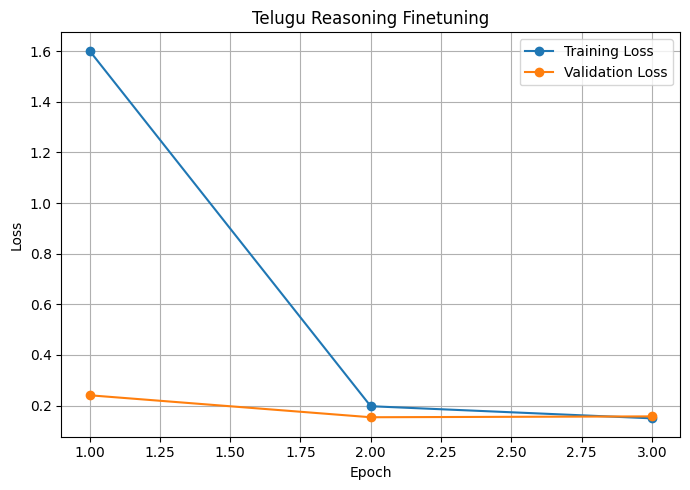

In [48]:
# ============================================================
# CELL 48 — FINETUNING LOSS CURVE
# ============================================================

import matplotlib.pyplot as plt


epochs = [
    x["epoch"]
    for x in training_history
]


train_losses = [
    x["train_loss"]
    for x in training_history
]


validation_losses = [
    x["validation_loss"]
    for x in training_history
]


plt.figure(
    figsize=(7, 5)
)


plt.plot(
    epochs,
    train_losses,
    marker="o",
    label="Training Loss"
)


plt.plot(
    epochs,
    validation_losses,
    marker="o",
    label="Validation Loss"
)


plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Telugu Reasoning Finetuning"
)

plt.legend()

plt.grid()

plt.tight_layout()


plt.savefig(
    PHASE3_DIR
    / "finetuning_loss.png",
    dpi=200
)


plt.show()

## Load the best finetuned checkpoint

Restores the lowest-validation-loss weights and reports which epoch won. Everything downstream evaluates *this* model.


In [49]:
# ============================================================
# CELL 49 — LOAD BEST FINETUNED MODEL
# ============================================================

best_checkpoint = torch.load(
    BEST_FT_CHECKPOINT,
    map_location=device,
    weights_only=False
)


model.load_state_dict(
    best_checkpoint[
        "model_state_dict"
    ],
    strict=True
)


model.eval()


print(
    "Best epoch:",
    best_checkpoint[
        "epoch"
    ] + 1
)


print(
    "Best validation loss:",
    best_checkpoint[
        "val_loss"
    ]
)


print(
    "✓ Best finetuned model loaded."
)

Best epoch: 2
Best validation loss: 0.15391349376489719
✓ Best finetuned model loaded.


## Quick qualitative check

Ten test examples through the finetuned model, side by side with the gold answers. Fast read on whether the output format was learned at all.


In [50]:
# ============================================================
# CELL 50 — FINETUNED QUICK TEST
# ============================================================

for example in test_examples[:10]:

    prediction = generate_reasoning_answer(
        model,
        example["prompt"]
    )


    prediction = normalize_answer(
        prediction
    )


    gold = normalize_answer(
        example["answer"]
    )


    print(
        "\n" + "=" * 70
    )


    print(
        "Template:",
        example["template"]
    )


    print("\nQuestion:")

    print(
        example["prompt"]
    )


    print(
        "\nGold answer:",
        gold
    )


    print(
        "Finetuned answer:",
        prediction
    )


    print(
        "Correct:",
        prediction == gold
    )
    


Template: T5

Question:
తరుణ్ వద్ద ఎరుపు బ్యాగ్ ఉంది.
అనితకి మామిడిపండ్లు ఇష్టం.
లత హారిక కంటే ఎత్తుగా ఉన్నారు.
హారిక అనిత కంటే ఎత్తుగా ఉన్నారు.
అనిత తరుణ్ కంటే ఎత్తుగా ఉన్నారు.
లత, తరుణ్ — వీరిలో ఎవరు ఎత్తుగా ఉన్నారు?

Gold answer: లత
Finetuned answer: లత
Correct: True

Template: T6

Question:
భరత్తో పోలిస్తే మేఘన ఎక్కువ మార్కులు సాధించారు.
మేఘనతో పోలిస్తే రోహిత్ ఎక్కువ మార్కులు సాధించారు.
రోహిత్ పవన్ కంటే తక్కువ మార్కులు సాధించారు.
పవన్, భరత్ — వీరిలో ఎవరు తక్కువ మార్కులు సాధించారు?

Gold answer: భరత్
Finetuned answer: భరత్
Correct: True

Template: T3

Question:
వర్ష దీపక్ కంటే ఎత్తుగా ఉన్నారు.
దీపక్ స్వాతి కంటే ఎత్తుగా ఉన్నారు.
వర్ష, స్వాతి — వీరిలో ఎవరు పొట్టిగా ఉన్నారు?

Gold answer: స్వాతి
Finetuned answer: స్వాతి
Correct: True

Template: T3

Question:
సీత గోపాల్ కంటే ఎక్కువ మార్కులు సాధించారు.
ప్రణయ్తో పోలిస్తే గోపాల్ ఎక్కువ మార్కులు సాధించారు.
సీత, ప్రణయ్ — వీరిలో ఎవరు తక్కువ మార్కులు సాధించారు?

Gold answer: ప్రణయ్
Finetuned answer: ప్రణయ్
Correct: True

Template: T2

Questio

## Finetuned test evaluation

Full 1200-example evaluation using the identical `evaluate_reasoning` function used for the baseline.


In [51]:
# ============================================================
# CELL 51 — FINETUNED TEST EVALUATION
# ============================================================

finetuned_metrics, finetuned_results = (
    evaluate_reasoning(

        model,

        test_examples,

        description=(
            "Finetuned reasoning evaluation"
        )
    )
)

Finetuned reasoning evaluation:   0%|          | 0/1200 [00:00<?, ?it/s]

## Print the finetuned numbers

Overall and per-template accuracy after finetuning.


In [52]:
print(
    "\n" + "=" * 60
)

print(
    "FINETUNED REASONING RESULTS"
)

print(
    "=" * 60
)


print(
    "\nTotal test examples:",
    finetuned_metrics[
        "total_examples"
    ]
)


print(
    "Correct:",
    finetuned_metrics[
        "correct_examples"
    ]
)


print(
    "Overall exact-match accuracy:",
    f"{finetuned_metrics['overall_exact_match']:.4f}"
)


print(
    "\nTemplate-wise accuracy:"
)


for template, accuracy in (
    finetuned_metrics[
        "template_accuracy"
    ].items()
):

    print(
        f"{template}: "
        f"{accuracy:.4f}"
    )


FINETUNED REASONING RESULTS

Total test examples: 1200
Correct: 981
Overall exact-match accuracy: 0.8175

Template-wise accuracy:
T1: 0.5650
T2: 0.3400
T3: 1.0000
T4: 1.0000
T5: 1.0000
T6: 1.0000


## Save finetuned metrics and predictions

Writes `finetuned_reasoning_metrics.json` and the full prediction dump.


In [53]:
# ============================================================
# CELL 52 — SAVE FINETUNED RESULTS
# ============================================================

with open(
    PHASE3_DIR
    / "finetuned_reasoning_metrics.json",

    "w",

    encoding="utf-8"
) as f:

    json.dump(
        finetuned_metrics,
        f,
        ensure_ascii=False,
        indent=2
    )


with open(
    PHASE3_DIR
    / "finetuned_test_predictions.json",

    "w",

    encoding="utf-8"
) as f:

    json.dump(
        finetuned_results,
        f,
        ensure_ascii=False,
        indent=2
    )


print(
    "✓ Finetuned results saved."
)

✓ Finetuned results saved.


## Pretrained vs finetuned comparison table

Joins both result sets into one table with an `Improvement` column and saves it to CSV. **This is the headline result of the phase** — and the per-template rows are the interesting part, since T1/T2 (direct comparison) and T3–T6 (multi-hop) should improve very differently.


In [54]:
# ============================================================
# CELL 53 — PRETRAINED VS FINETUNED
# ============================================================

comparison_rows = []


comparison_rows.append({

    "Template": "Overall",

    "Pretrained":
        pretrained_metrics[
            "overall_exact_match"
        ],

    "Finetuned":
        finetuned_metrics[
            "overall_exact_match"
        ]
})


for template in [
    "T1",
    "T2",
    "T3",
    "T4",
    "T5",
    "T6"
]:

    comparison_rows.append({

        "Template":
            template,

        "Pretrained":
            pretrained_metrics[
                "template_accuracy"
            ][template],

        "Finetuned":
            finetuned_metrics[
                "template_accuracy"
            ][template]
    })


comparison_df = pd.DataFrame(
    comparison_rows
)


comparison_df[
    "Improvement"
] = (
    comparison_df[
        "Finetuned"
    ]
    -
    comparison_df[
        "Pretrained"
    ]
)


print(
    comparison_df.to_string(
        index=False
    )
)


comparison_df.to_csv(
    PHASE3_DIR
    / "pretrained_vs_finetuned.csv",
    index=False
)

Template  Pretrained  Finetuned  Improvement
 Overall         0.0     0.8175       0.8175
      T1         0.0     0.5650       0.5650
      T2         0.0     0.3400       0.3400
      T3         0.0     1.0000       1.0000
      T4         0.0     1.0000       1.0000
      T5         0.0     1.0000       1.0000
      T6         0.0     1.0000       1.0000


## T1 validation error inspection

Prints 20 T1 validation predictions against gold. T1 is the easiest template, so persistent errors here point at a format or tokenisation bug rather than a reasoning failure.


In [55]:
# ============================================================
# CHECK T1 VALIDATION PREDICTIONS
# ============================================================

t1_val = [
    x for x in val_examples
    if x["template"] == "T1"
]

for example in t1_val[:20]:

    prediction = generate_reasoning_answer(
        model,
        example["prompt"]
    )

    prediction = normalize_answer(
        prediction
    )

    gold = normalize_answer(
        example["answer"]
    )

    print("\n" + "=" * 60)
    print(example["prompt"])

    print("\nGold      :", gold)
    print("Prediction:", prediction)
    print("Correct   :", prediction == gold)


విక్రమ్ వయస్సు 68 సంవత్సరాలు.
సందీప్ వయస్సు 35 సంవత్సరాలు.
విక్రమ్, సందీప్ — వీరిలో ఎవరి వయస్సు ఎక్కువ?

Gold      : విక్రమ్
Prediction: సందీప్
Correct   : False

సురేష్ వద్ద 19 పుస్తకాలు ఉన్నాయి.
హారిక వద్ద 81 పుస్తకాలు ఉన్నాయి.
సురేష్, హారిక — వీరిలో ఎవరి వద్ద తక్కువ పుస్తకాలు ఉన్నాయి?

Gold      : సురేష్
Prediction: హారిక
Correct   : False

అర్జున్ వద్ద 3970 రూపాయలు ఉన్నాయి.
సురేష్ వద్ద 1365 రూపాయలు ఉన్నాయి.
అర్జున్, సురేష్ — వీరిలో ఎవరి వద్ద తక్కువ డబ్బు ఉంది?

Gold      : సురేష్
Prediction: సురేష్
Correct   : True

హారిక వద్ద 2371 రూపాయలు ఉన్నాయి.
దీప్తి వద్ద 1384 రూపాయలు ఉన్నాయి.
హారిక, దీప్తి — వీరిలో ఎవరి వద్ద తక్కువ డబ్బు ఉంది?

Gold      : దీప్తి
Prediction: హారిక
Correct   : False

దీపక్ వయస్సు 18 సంవత్సరాలు.
నవీన్ వయస్సు 37 సంవత్సరాలు.
దీపక్, నవీన్ — వీరిలో ఎవరి వయస్సు ఎక్కువ?

Gold      : నవీన్
Prediction: నవీన్
Correct   : True

అనిత వద్ద 56 పుస్తకాలు ఉన్నాయి.
శ్రావ్య వద్ద 47 పుస్తకాలు ఉన్నాయి.
అనిత, శ్రావ్య — వీరిలో ఎవరి వద్ద తక్కువ పుస్తకాలు ఉన్నాయి?

Gold      : శ్రావ

## Re-echo the data paths

Repeat of cell 1.


In [56]:
print("TRAIN FILE:", TRAIN_FILE)
print("VAL FILE  :", VAL_FILE)
print("TEST FILE :", TEST_FILE)

TRAIN FILE: /kaggle/input/datasets/tanoojtadepalli/final-telugu-phase3/telugu_reasoning_dataset_shared_names/train.jsonl
VAL FILE  : /kaggle/input/datasets/tanoojtadepalli/final-telugu-phase3/telugu_reasoning_dataset_shared_names/validation.jsonl
TEST FILE : /kaggle/input/datasets/tanoojtadepalli/final-telugu-phase3/telugu_reasoning_dataset_shared_names/test.jsonl


## Load both models side by side

Instantiates `pretrained_model` and `finetuned_model` simultaneously so the same input can be pushed through both, and creates the `attention_analysis` output folder.


In [58]:
# ============================================================
# CELL 54 — LOAD PRETRAINED AND FINETUNED MODELS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ATTN_DIR = (
    PHASE3_DIR
    / "attention_analysis"
)

ATTN_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# PRETRAINED MODEL
# ------------------------------------------------------------

pretrained_model = Transformer(
    config
).to(device)

pretrained_checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False
)

pretrained_model.load_state_dict(
    pretrained_checkpoint[
        "model_state_dict"
    ],
    strict=True
)

pretrained_model.eval()


# ------------------------------------------------------------
# FINETUNED MODEL
# ------------------------------------------------------------

finetuned_model = Transformer(
    config
).to(device)

finetuned_checkpoint = torch.load(
    BEST_FT_CHECKPOINT,
    map_location=device,
    weights_only=False
)

finetuned_model.load_state_dict(
    finetuned_checkpoint[
        "model_state_dict"
    ],
    strict=True
)

finetuned_model.eval()


print("✓ Pretrained model loaded")
print("✓ Finetuned model loaded")

print(
    "Best finetuned epoch:",
    finetuned_checkpoint["epoch"] + 1
)

✓ Pretrained model loaded
✓ Finetuned model loaded
Best finetuned epoch: 2


## Pick a prompt for attention analysis

Scans the test set for the first **T6** example the finetuned model gets right. T6 is the hardest template — mixed-direction wording plus a 3-hop chain — so its attention pattern is the most informative thing to visualise.

Note the selection bias: this is a cherry-picked success, so the heatmaps illustrate rather than prove.


In [59]:
# ============================================================
# CELL 55 — SELECT REASONING PROMPT
# ============================================================

attention_example = None


for example in test_examples:

    if example["template"] != "T6":
        continue

    prediction = generate_reasoning_answer(
        finetuned_model,
        example["prompt"]
    )

    prediction = normalize_answer(
        prediction
    )

    gold = normalize_answer(
        example["answer"]
    )

    if prediction == gold:

        attention_example = example
        break


assert attention_example is not None


print("=" * 70)
print("ATTENTION ANALYSIS EXAMPLE")
print("=" * 70)

print(
    "\nTemplate:",
    attention_example["template"]
)

print("\nQuestion:")
print(
    attention_example["prompt"]
)

print(
    "\nGold answer:",
    attention_example["answer"]
)

ATTENTION ANALYSIS EXAMPLE

Template: T6

Question:
భరత్తో పోలిస్తే మేఘన ఎక్కువ మార్కులు సాధించారు.
మేఘనతో పోలిస్తే రోహిత్ ఎక్కువ మార్కులు సాధించారు.
రోహిత్ పవన్ కంటే తక్కువ మార్కులు సాధించారు.
పవన్, భరత్ — వీరిలో ఎవరు తక్కువ మార్కులు సాధించారు?

Gold answer: భరత్


## Both models' predictions on that prompt

Prints gold, pretrained and finetuned answers for the chosen example, so the heatmaps below have a known behavioural difference attached to them.


In [60]:
# ============================================================
# CELL 56 — PREDICTIONS ON SAME PROMPT
# ============================================================

pretrained_prediction = (
    generate_reasoning_answer(
        pretrained_model,
        attention_example["prompt"]
    )
)


finetuned_prediction = (
    generate_reasoning_answer(
        finetuned_model,
        attention_example["prompt"]
    )
)


print(
    "Gold       :",
    attention_example["answer"]
)

print(
    "Pretrained :",
    pretrained_prediction
)

print(
    "Finetuned  :",
    finetuned_prediction
)

Gold       : భరత్
Pretrained : మరియుమరియుమరియుమ
Finetuned  : భరత్


## Tokenize the analysis prompt

Encodes prompt + answer prefix into a single batch-of-one tensor and keeps the SentencePiece `pieces` for axis labels. Only the question is fed in — the model is attending as it is about to produce the answer.


In [61]:
# ============================================================
# CELL 57 — BUILD ATTENTION INPUT
# ============================================================

attention_text = (
    QUESTION_PREFIX
    + attention_example["prompt"]
    + ANSWER_PREFIX
)


attention_ids = sp.encode(
    attention_text,
    out_type=int
)


attention_tensor = torch.tensor(
    attention_ids,
    dtype=torch.long,
    device=device
).unsqueeze(0)


pieces = [
    sp.id_to_piece(token_id)
    for token_id in attention_ids
]


print(
    "Number of tokens:",
    len(attention_ids)
)

print(
    "\nInput text:"
)

print(attention_text)

Number of tokens: 57

Input text:
ప్రశ్న:
భరత్తో పోలిస్తే మేఘన ఎక్కువ మార్కులు సాధించారు.
మేఘనతో పోలిస్తే రోహిత్ ఎక్కువ మార్కులు సాధించారు.
రోహిత్ పవన్ కంటే తక్కువ మార్కులు సాధించారు.
పవన్, భరత్ — వీరిలో ఎవరు తక్కువ మార్కులు సాధించారు?
సమాధానం:



## Extract attention matrices

Runs both models with `return_attentions=True` and strips the batch dimension, leaving a per-layer `[heads, seq, seq]` tensor moved to CPU.


In [62]:
# ============================================================
# CELL 58 — EXTRACT ATTENTION MATRICES
# ============================================================

@torch.inference_mode()
def extract_attentions(
    model,
    input_tensor
):

    model.eval()

    output = model(
        input_tensor,
        return_attentions=True
    )


    # Expected:
    #
    # logits, attentions
    #
    logits, attentions = output


    # Convert:
    #
    # [batch, heads, seq, seq]
    #
    # to:
    #
    # [heads, seq, seq]
    #

    attentions = [

        layer_attention[0]
        .detach()
        .cpu()

        for layer_attention
        in attentions
    ]


    return (
        logits,
        attentions
    )


_, pretrained_attentions = (
    extract_attentions(
        pretrained_model,
        attention_tensor
    )
)


_, finetuned_attentions = (
    extract_attentions(
        finetuned_model,
        attention_tensor
    )
)


print(
    "Number of layers:",
    len(pretrained_attentions)
)

print(
    "Attention shape:",
    pretrained_attentions[0].shape
)

Number of layers: 12
Attention shape: torch.Size([8, 57, 57])


## Attention shape sanity check

Asserts 12 layers for each model and identical shapes layer by layer — necessary before comparing them numerically.


In [63]:
# ============================================================
# CELL 59 — ATTENTION SANITY CHECK
# ============================================================

assert (
    len(pretrained_attentions)
    == config["n_layers"]
)

assert (
    len(finetuned_attentions)
    == config["n_layers"]
)


for layer in range(
    config["n_layers"]
):

    assert (
        pretrained_attentions[layer].shape
        ==
        finetuned_attentions[layer].shape
    )


print(
    "✓ Attention tensors verified."
)

✓ Attention tensors verified.


## Build token axis labels

Truncates long SentencePiece pieces to 12 characters so the heatmap axes stay readable, and prints the index→token map for locating names in the plots.


In [64]:
# ============================================================
# CELL 60 — TOKEN LABELS
# ============================================================

def clean_piece(piece):

    piece = piece.replace(
        "▁",
        "▁"
    )

    if len(piece) > 12:
        piece = piece[:12] + "…"

    return piece


token_labels = [
    clean_piece(x)
    for x in pieces
]


for i, token in enumerate(
    token_labels
):

    print(
        i,
        token
    )

0 ▁ప్రశ్న
1 <0x3A>
2 <0x0A>
3 భ
4 ర
5 త్
6 తో
7 ▁పోలిస్తే
8 ▁మేఘ
9 న
10 ▁ఎక్కువ
11 ▁మార్కులు
12 ▁సాధించారు
13 .
14 <0x0A>
15 మే
16 ఘ
17 న
18 తో
19 ▁పోలిస్తే
20 ▁రోహిత్
21 ▁ఎక్కువ
22 ▁మార్కులు
23 ▁సాధించారు
24 .
25 <0x0A>
26 రో
27 హి
28 త్
29 ▁పవన్
30 ▁కంటే
31 ▁తక్కువ
32 ▁మార్కులు
33 ▁సాధించారు
34 .
35 <0x0A>
36 ప
37 వన్
38 ,
39 ▁భరత్
40 ▁
41 <0xE2>
42 <0x80>
43 <0x94>
44 ▁వీరిలో
45 ▁ఎవరు
46 ▁తక్కువ
47 ▁మార్కులు
48 ▁సాధించారు
49 ?
50 <0x0A>
51 స
52 మా
53 ధా
54 నం
55 <0x3A>
56 <0x0A>


## Heatmap plotting function

Plots a `[seq, seq]` attention matrix — either one specific head or the mean across all heads. Figure size and label density scale with sequence length. Every plot is saved to disk.

Remember the matrix is lower-triangular by construction: the upper triangle is masked, not empty of interest.


In [65]:
# ============================================================
# CELL 61 — ATTENTION HEATMAP FUNCTION
# ============================================================

def plot_attention_heatmap(
    attention,
    labels,
    title,
    save_path,
    head=None
):

    # attention:
    # [heads, seq, seq]


    if head is None:

        matrix = (
            attention
            .mean(dim=0)
            .numpy()
        )

        head_label = (
            "Average of all heads"
        )

    else:

        matrix = (
            attention[head]
            .numpy()
        )

        head_label = (
            f"Head {head + 1}"
        )


    seq_len = len(labels)


    figure_size = max(
        9,
        min(
            18,
            seq_len * 0.25
        )
    )


    plt.figure(
        figsize=(
            figure_size,
            figure_size
        )
    )


    plt.imshow(
        matrix,
        aspect="auto",
        interpolation="nearest"
    )


    plt.colorbar(
        label="Attention Weight"
    )


    # Reduce label density for long sequences
    step = max(
        1,
        seq_len // 35
    )


    ticks = list(
        range(
            0,
            seq_len,
            step
        )
    )


    plt.xticks(
        ticks,
        [
            labels[i]
            for i in ticks
        ],
        rotation=90,
        fontsize=7
    )


    plt.yticks(
        ticks,
        [
            labels[i]
            for i in ticks
        ],
        fontsize=7
    )


    plt.xlabel(
        "Key Tokens"
    )

    plt.ylabel(
        "Query Tokens"
    )


    plt.title(
        title
        + "\n"
        + head_label
    )


    plt.tight_layout()


    plt.savefig(
        save_path,
        dpi=200,
        bbox_inches="tight"
    )


    plt.show()
    

## Early vs late layer heatmaps

Renders four maps — pretrained/finetuned × layer 1/layer 12. The expected story: early layers look local and positional in both models, while the late layer diverges, with the finetuned model reaching back to the entity names in the facts.


/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 3114 (\N{TELUGU LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Matplotlib currently does not support Telugu natively.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 3149 (\N{TELUGU SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 3120 (\N{TELUGU LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 3126 (\N{TELUGU LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 3112 (\N{TELUGU LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 3117 (\N{TELUGU LETTER BHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126:

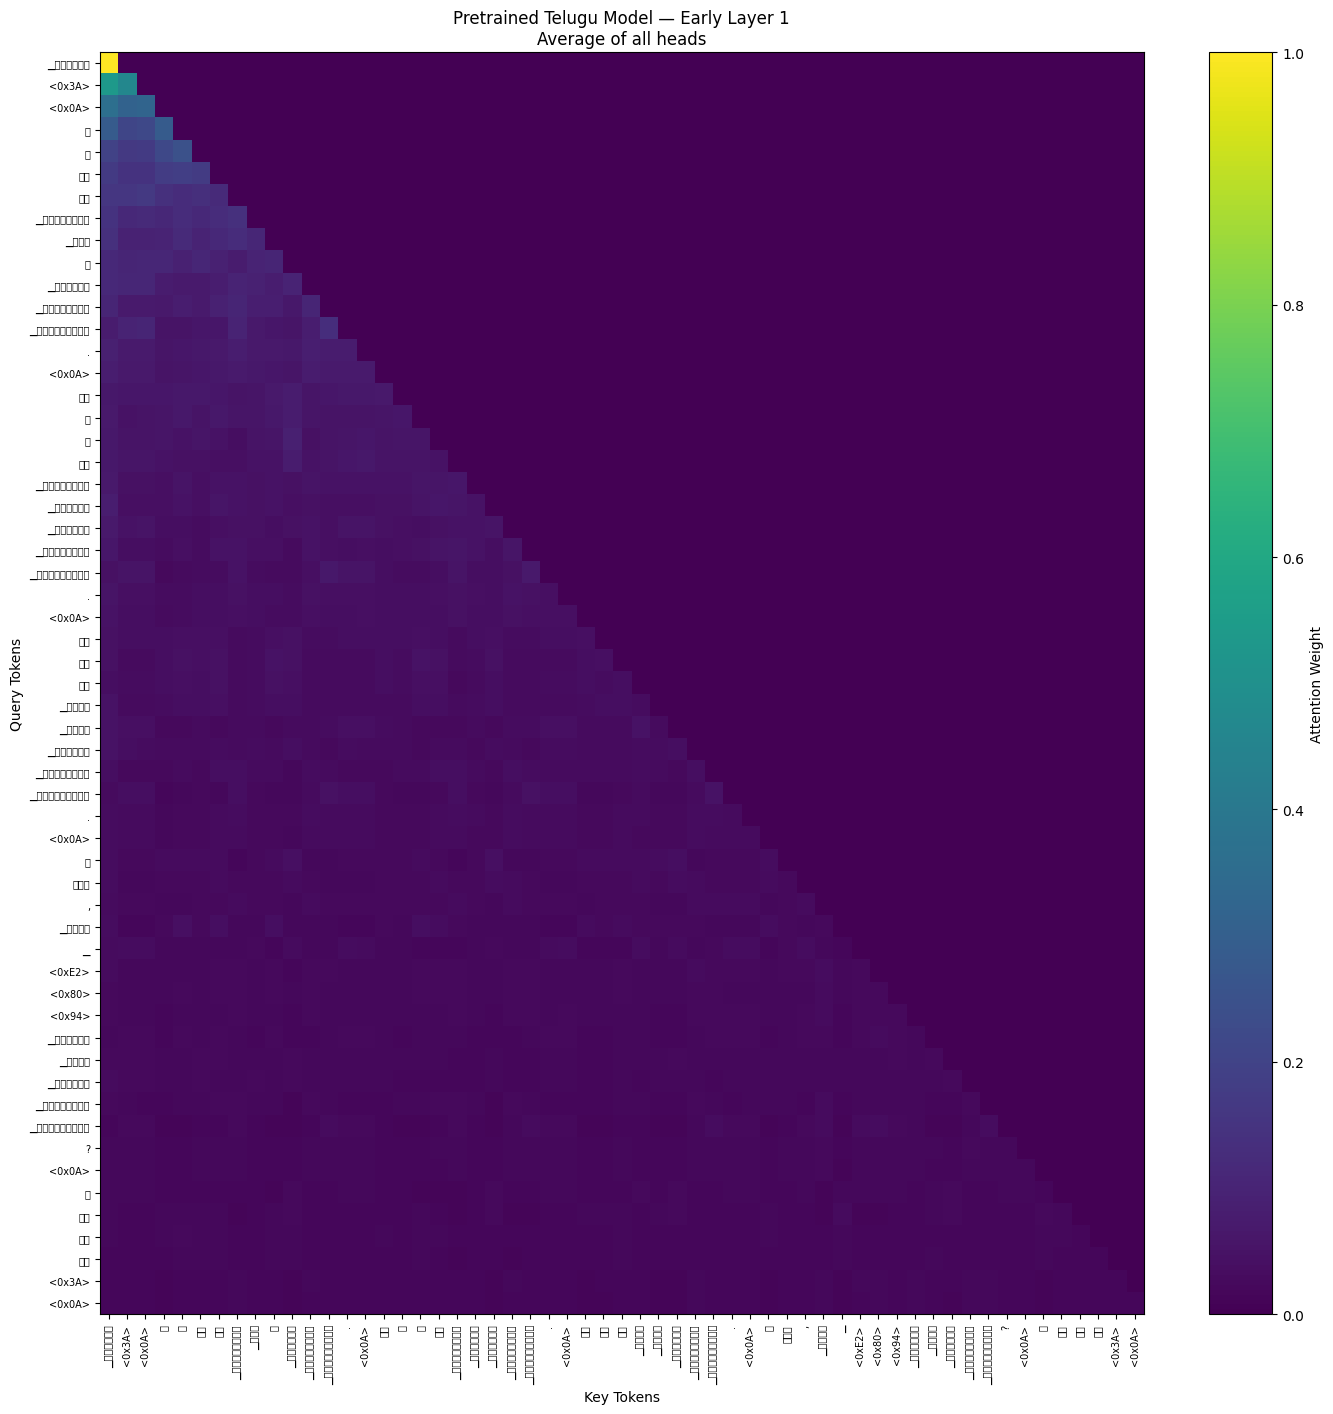

/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 3114 (\N{TELUGU LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Matplotlib currently does not support Telugu natively.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 3149 (\N{TELUGU SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 3120 (\N{TELUGU LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 3126 (\N{TELUGU LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 3112 (\N{TELUGU LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 3117 (\N{TELUGU LETTER BHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126:

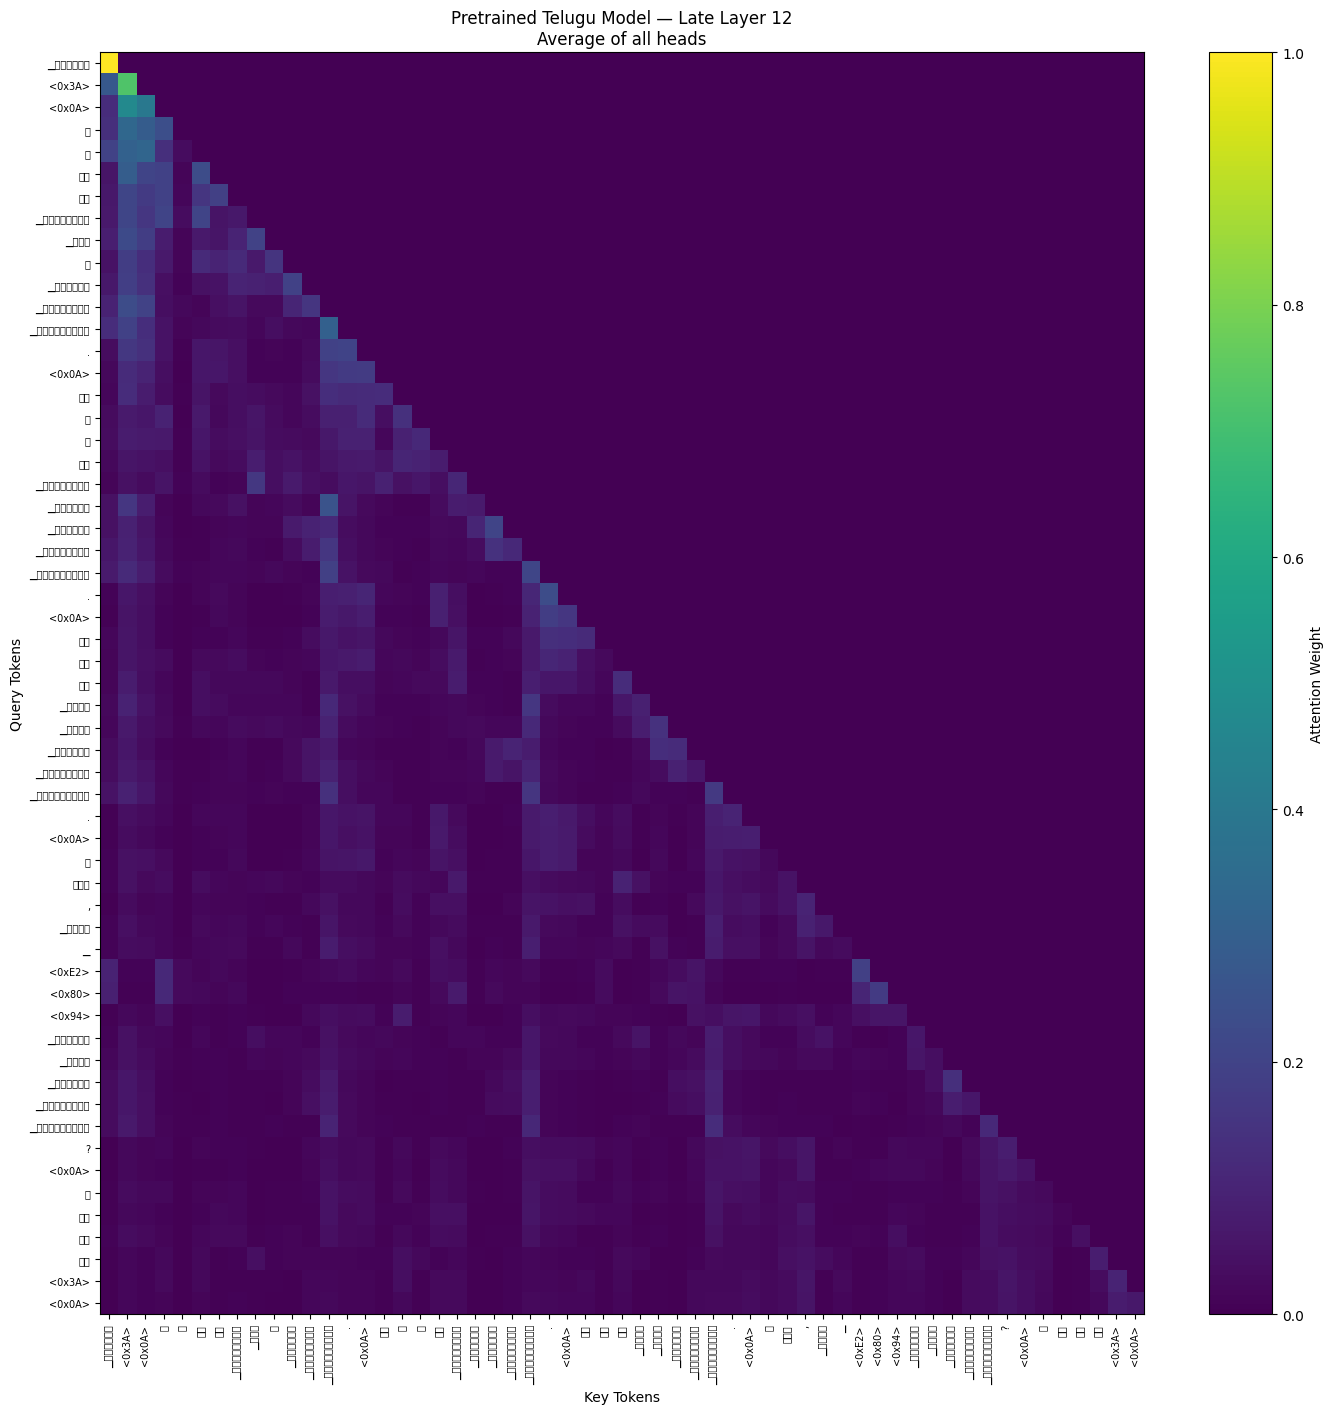

/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 3114 (\N{TELUGU LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Matplotlib currently does not support Telugu natively.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 3149 (\N{TELUGU SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 3120 (\N{TELUGU LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 3126 (\N{TELUGU LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 3112 (\N{TELUGU LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 3117 (\N{TELUGU LETTER BHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126:

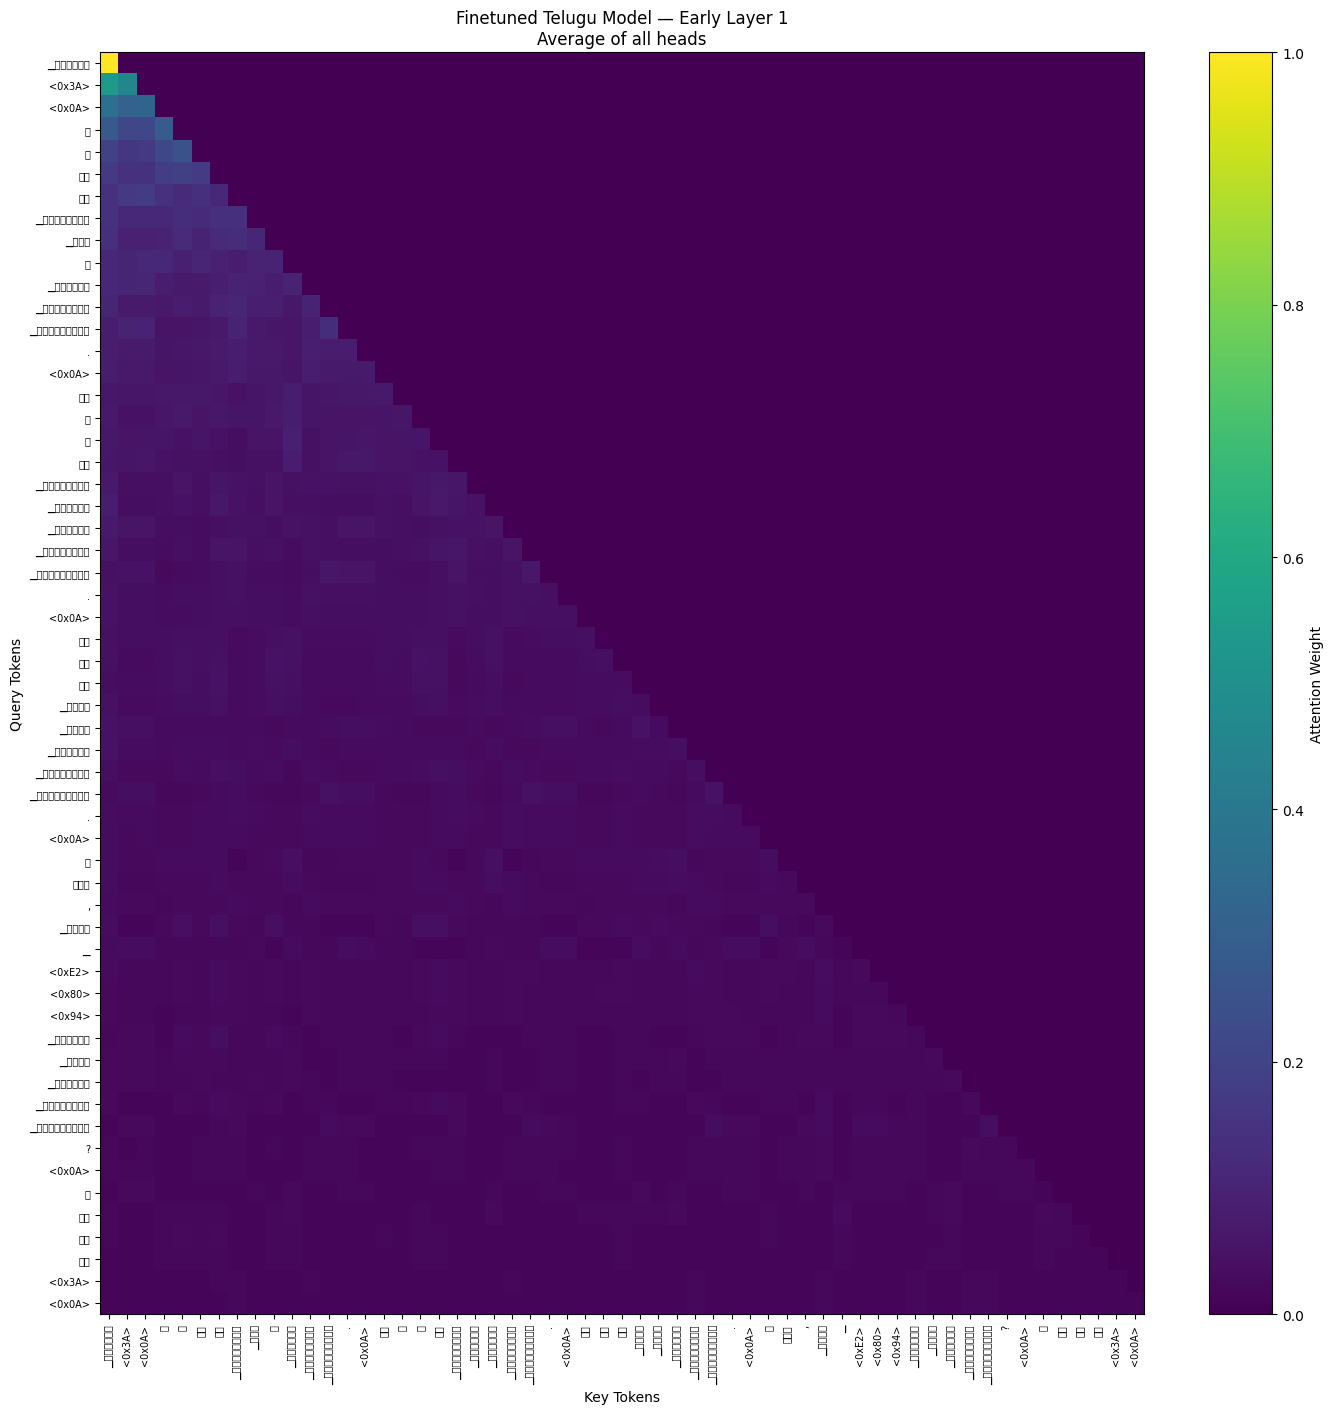

/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 3114 (\N{TELUGU LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Matplotlib currently does not support Telugu natively.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 3149 (\N{TELUGU SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 3120 (\N{TELUGU LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 3126 (\N{TELUGU LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 3112 (\N{TELUGU LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 3117 (\N{TELUGU LETTER BHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126:

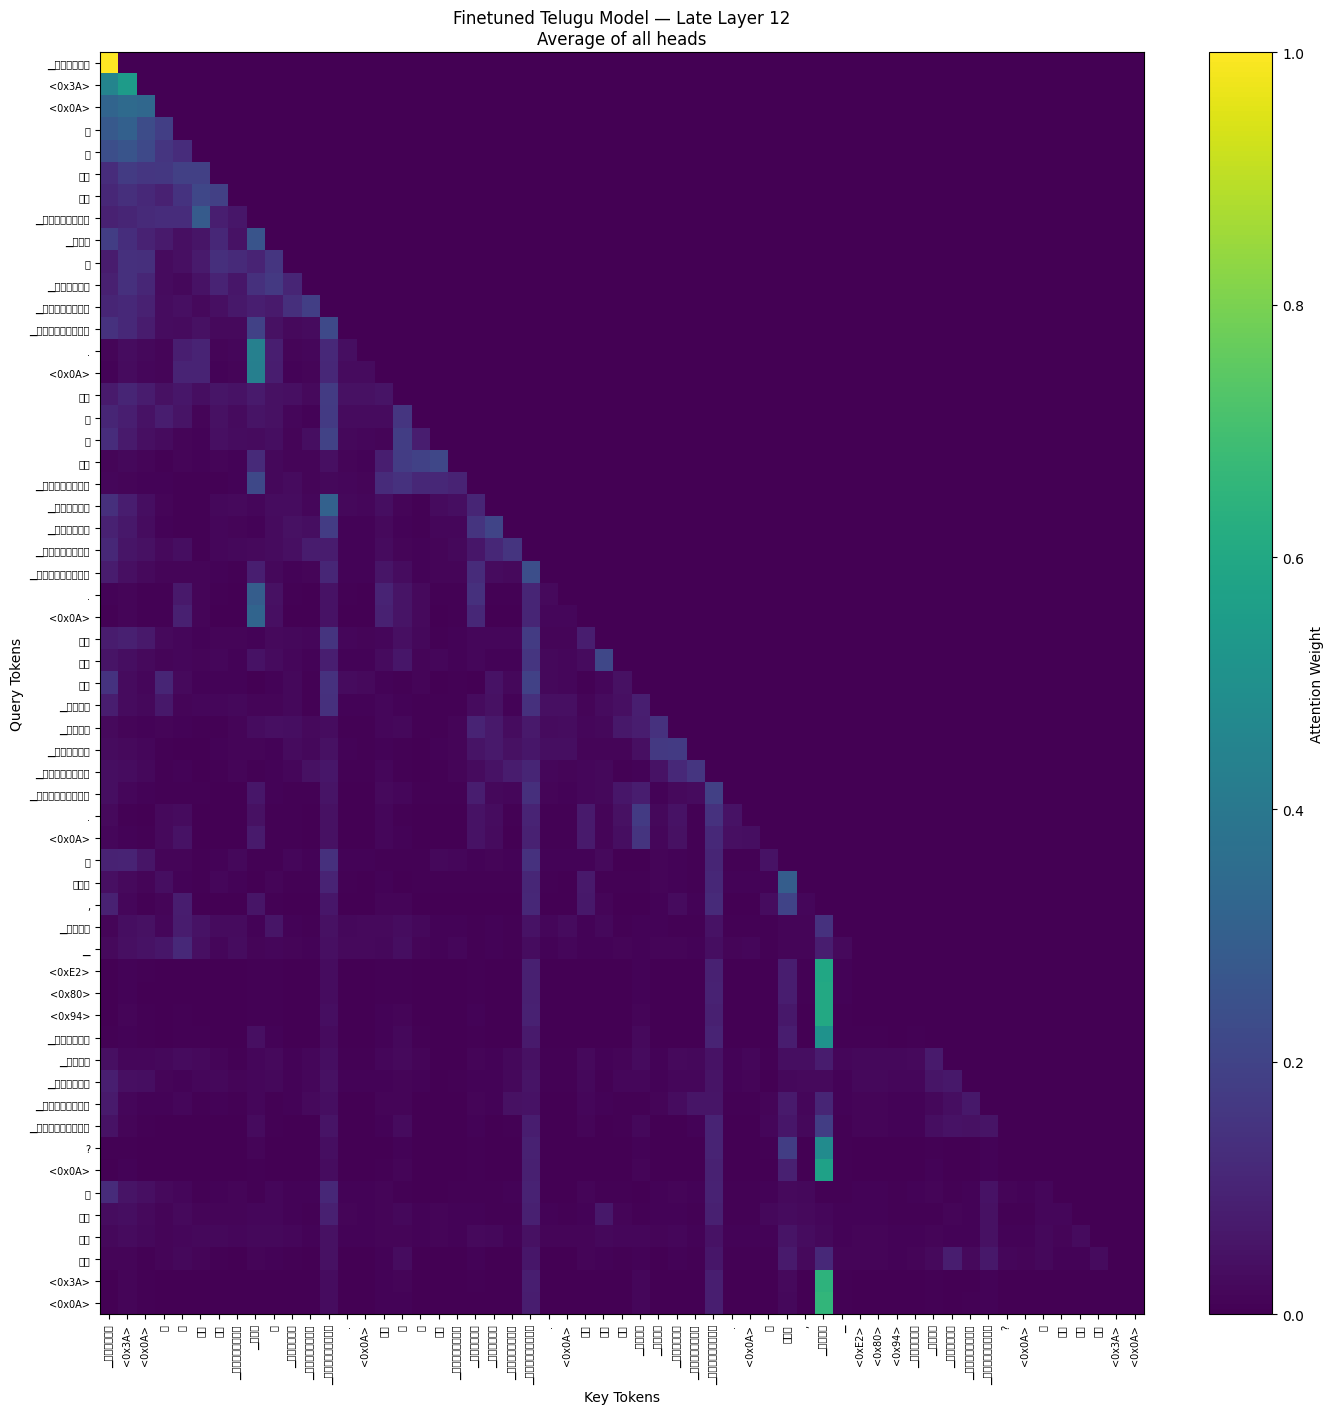

In [66]:
# ============================================================
# CELL 62 — PRETRAINED VS FINETUNED HEATMAPS
# ============================================================

EARLY_LAYER = 0

LATE_LAYER = (
    config["n_layers"] - 1
)


# ------------------------------------------------------------
# PRETRAINED — EARLY
# ------------------------------------------------------------

plot_attention_heatmap(

    pretrained_attentions[
        EARLY_LAYER
    ],

    token_labels,

    title=(
        "Pretrained Telugu Model"
        " — Early Layer"
        f" {EARLY_LAYER + 1}"
    ),

    save_path=(
        ATTN_DIR
        / "pretrained_early_layer.png"
    )
)


# ------------------------------------------------------------
# PRETRAINED — LATE
# ------------------------------------------------------------

plot_attention_heatmap(

    pretrained_attentions[
        LATE_LAYER
    ],

    token_labels,

    title=(
        "Pretrained Telugu Model"
        " — Late Layer"
        f" {LATE_LAYER + 1}"
    ),

    save_path=(
        ATTN_DIR
        / "pretrained_late_layer.png"
    )
)


# ------------------------------------------------------------
# FINETUNED — EARLY
# ------------------------------------------------------------

plot_attention_heatmap(

    finetuned_attentions[
        EARLY_LAYER
    ],

    token_labels,

    title=(
        "Finetuned Telugu Model"
        " — Early Layer"
        f" {EARLY_LAYER + 1}"
    ),

    save_path=(
        ATTN_DIR
        / "finetuned_early_layer.png"
    )
)


# ------------------------------------------------------------
# FINETUNED — LATE
# ------------------------------------------------------------

plot_attention_heatmap(

    finetuned_attentions[
        LATE_LAYER
    ],

    token_labels,

    title=(
        "Finetuned Telugu Model"
        " — Late Layer"
        f" {LATE_LAYER + 1}"
    ),

    save_path=(
        ATTN_DIR
        / "finetuned_late_layer.png"
    )
)

## Attention metrics per head

Reduces each head to two numbers, computed only over allowed (causal) positions:

- **Normalized entropy** — how spread out the attention is. Low = sharply focused on a few tokens; high = diffuse.
- **Mean attention distance** — average token distance between query and attended key. High = long-range, which is what multi-hop chaining requires.

This is what turns "the heatmaps look different" into something measurable.


In [67]:
# ============================================================
# CELL 63 — ATTENTION METRICS
# ============================================================

def compute_attention_metrics(
    attention_layers,
    model_name
):

    rows = []


    for layer_index, attention in enumerate(
        attention_layers
    ):

        # attention:
        # [heads, seq, seq]

        num_heads = attention.shape[0]
        seq_len = attention.shape[1]


        for head_index in range(
            num_heads
        ):

            head_attention = (
                attention[
                    head_index
                ]
                .numpy()
            )


            entropy_values = []
            distance_values = []


            for query_position in range(
                seq_len
            ):

                # Causal model:
                # Only positions <= query_position
                # are allowed.

                probs = (
                    head_attention[
                        query_position,
                        :query_position + 1
                    ]
                )


                total = probs.sum()


                if total <= 0:
                    continue


                probs = (
                    probs / total
                )


                # --------------------------------------------
                # NORMALIZED ENTROPY
                # --------------------------------------------

                if query_position > 0:

                    entropy = -np.sum(

                        probs
                        * np.log(
                            probs + 1e-12
                        )
                    )


                    max_entropy = (
                        np.log(
                            query_position + 1
                        )
                    )


                    normalized_entropy = (
                        entropy
                        / max_entropy
                    )


                    entropy_values.append(
                        normalized_entropy
                    )


                # --------------------------------------------
                # MEAN ATTENTION DISTANCE
                # --------------------------------------------

                key_positions = np.arange(
                    query_position + 1
                )


                distances = (
                    query_position
                    - key_positions
                )


                mean_distance = np.sum(
                    probs * distances
                )


                distance_values.append(
                    mean_distance
                )


            rows.append({

                "Model":
                    model_name,

                "Layer":
                    layer_index + 1,

                "Head":
                    head_index + 1,

                "Normalized_Entropy":
                    float(
                        np.mean(
                            entropy_values
                        )
                    ),

                "Mean_Attention_Distance":
                    float(
                        np.mean(
                            distance_values
                        )
                    ),
            })


    return pd.DataFrame(
        rows
    )

## Compute metrics for both models

Runs the metric function over all layers and heads of both models, concatenates into one dataframe, and saves `attention_metrics_all_heads.csv`.


In [68]:
# ============================================================
# CELL 64 — PRETRAINED VS FINETUNED METRICS
# ============================================================

pretrained_attention_metrics = (
    compute_attention_metrics(
        pretrained_attentions,
        "Pretrained"
    )
)


finetuned_attention_metrics = (
    compute_attention_metrics(
        finetuned_attentions,
        "Finetuned"
    )
)


attention_metrics_df = pd.concat(

    [
        pretrained_attention_metrics,
        finetuned_attention_metrics
    ],

    ignore_index=True
)


attention_metrics_df.to_csv(

    ATTN_DIR
    / "attention_metrics_all_heads.csv",

    index=False
)


print(
    attention_metrics_df.head()
)

        Model  Layer  Head  Normalized_Entropy  Mean_Attention_Distance
0  Pretrained      1     1            0.987379                14.515414
1  Pretrained      1     2            0.996222                14.135223
2  Pretrained      1     3            0.977623                13.868730
3  Pretrained      1     4            0.982596                13.450791
4  Pretrained      1     5            0.965401                14.001340


## Early vs late summary

Aggregates mean entropy and distance for layer 1 and layer 12 in each model — the compact before/after table.


In [69]:
# ============================================================
# CELL 65 — EARLY VS LATE SUMMARY
# ============================================================

summary_rows = []


for model_name in [
    "Pretrained",
    "Finetuned"
]:

    model_df = (
        attention_metrics_df[
            attention_metrics_df[
                "Model"
            ]
            == model_name
        ]
    )


    for label, layer_number in [

        (
            "Early",
            EARLY_LAYER + 1
        ),

        (
            "Late",
            LATE_LAYER + 1
        )
    ]:

        layer_df = (
            model_df[
                model_df[
                    "Layer"
                ]
                == layer_number
            ]
        )


        summary_rows.append({

            "Model":
                model_name,

            "Layer_Type":
                label,

            "Layer":
                layer_number,

            "Mean_Normalized_Entropy":
                layer_df[
                    "Normalized_Entropy"
                ].mean(),

            "Mean_Attention_Distance":
                layer_df[
                    "Mean_Attention_Distance"
                ].mean()
        })


attention_summary = pd.DataFrame(
    summary_rows
)


print(
    attention_summary.to_string(
        index=False
    )
)


attention_summary.to_csv(

    ATTN_DIR
    / "early_late_attention_summary.csv",

    index=False
)

     Model Layer_Type  Layer  Mean_Normalized_Entropy  Mean_Attention_Distance
Pretrained      Early      1                 0.981368                13.965325
Pretrained       Late     12                 0.730240                12.223185
 Finetuned      Early      1                 0.979634                14.010317
 Finetuned       Late     12                 0.621536                11.376847


## Entropy across layers

Plots mean normalized entropy per layer for both models. A finetuned curve that drops in the later layers indicates attention sharpened onto specific tokens rather than spreading evenly.


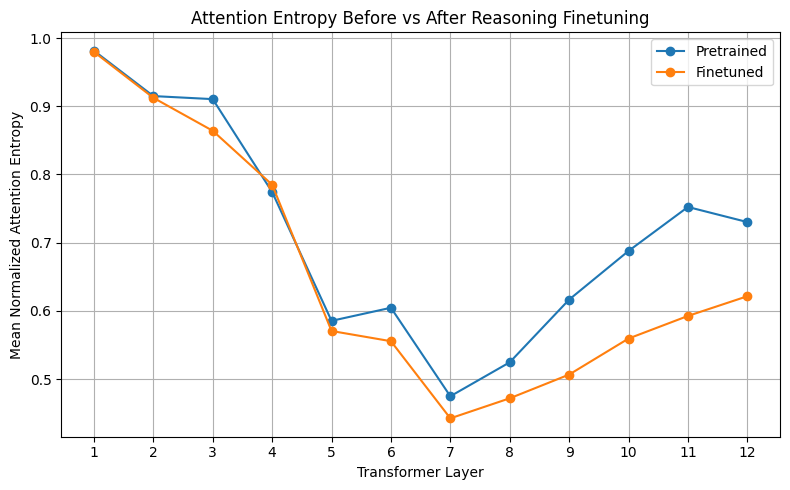

In [70]:
# ============================================================
# CELL 66 — ENTROPY ACROSS LAYERS
# ============================================================

layer_summary = (

    attention_metrics_df

    .groupby(
        [
            "Model",
            "Layer"
        ]
    )

    .agg(

        Mean_Entropy=(
            "Normalized_Entropy",
            "mean"
        ),

        Mean_Distance=(
            "Mean_Attention_Distance",
            "mean"
        )

    )

    .reset_index()
)


plt.figure(
    figsize=(8, 5)
)


for model_name in [
    "Pretrained",
    "Finetuned"
]:

    subset = (
        layer_summary[
            layer_summary[
                "Model"
            ]
            == model_name
        ]
    )


    plt.plot(
        subset["Layer"],
        subset["Mean_Entropy"],
        marker="o",
        label=model_name
    )


plt.xlabel("Transformer Layer")

plt.ylabel(
    "Mean Normalized Attention Entropy"
)

plt.title(
    "Attention Entropy Before vs After Reasoning Finetuning"
)

plt.xticks(
    range(
        1,
        config["n_layers"] + 1
    )
)

plt.legend()

plt.grid()

plt.tight_layout()


plt.savefig(
    ATTN_DIR
    / "attention_entropy_by_layer.png",
    dpi=200
)

plt.show()

## Attention distance across layers

Same, for mean attention distance. A rise in the finetuned late layers is the evidence for reasoning: the model is looking further back, toward the fact sentences, instead of only at nearby tokens.


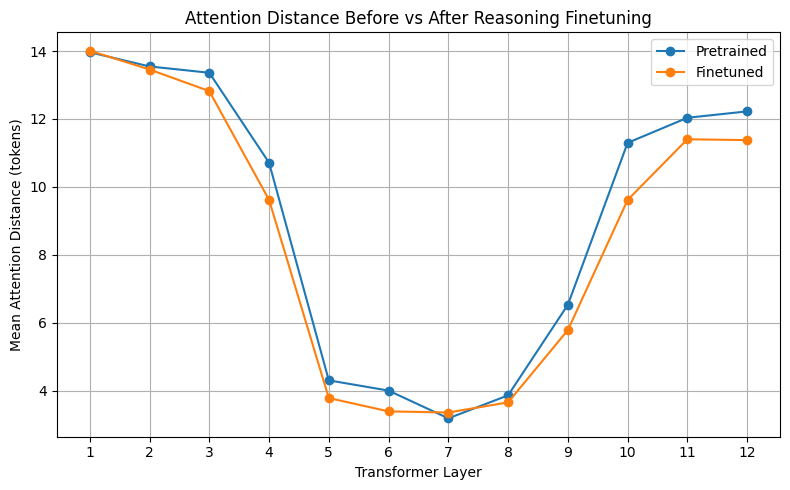

In [71]:
# ============================================================
# CELL 67 — ATTENTION DISTANCE ACROSS LAYERS
# ============================================================

plt.figure(
    figsize=(8, 5)
)


for model_name in [
    "Pretrained",
    "Finetuned"
]:

    subset = (
        layer_summary[
            layer_summary[
                "Model"
            ]
            == model_name
        ]
    )


    plt.plot(
        subset["Layer"],
        subset["Mean_Distance"],
        marker="o",
        label=model_name
    )


plt.xlabel(
    "Transformer Layer"
)

plt.ylabel(
    "Mean Attention Distance (tokens)"
)

plt.title(
    "Attention Distance Before vs After Reasoning Finetuning"
)

plt.xticks(
    range(
        1,
        config["n_layers"] + 1
    )
)

plt.legend()

plt.grid()

plt.tight_layout()


plt.savefig(
    ATTN_DIR
    / "attention_distance_by_layer.png",
    dpi=200
)

plt.show()

## Save the attention analysis record

Dumps the analysed example, both predictions, token count, the layer indices used and the chosen head to `attention_example.json`, so every figure in the writeup is traceable to its source.


In [75]:
# ============================================================
# CELL 71 — SAVE ATTENTION EXAMPLE
# ============================================================

attention_example_record = {

    "template":
        attention_example["template"],

    "prompt":
        attention_example["prompt"],

    "gold_answer":
        attention_example["answer"],

    "pretrained_prediction":
        pretrained_prediction,

    "finetuned_prediction":
        finetuned_prediction,

    "num_tokens":
        len(attention_ids),

    "early_layer":
        EARLY_LAYER + 1,

    "late_layer":
        LATE_LAYER + 1,

    "long_range_finetuned_head":
        long_range_head + 1
}


with open(
    ATTN_DIR
    / "attention_example.json",

    "w",

    encoding="utf-8"
) as f:

    json.dump(
        attention_example_record,
        f,
        ensure_ascii=False,
        indent=2
    )


print(
    "✓ Attention analysis saved to:"
)

print(
    ATTN_DIR
)

✓ Attention analysis saved to:
/kaggle/working/telugu_phase3/attention_analysis
